# Exposure Adjudication (Survey Snippet → Exposure Score)

**Notebook purpose**: Bridge the validated survey-to-O*NET task mapping (Notebook 5) with exposure scores (Notebook 01_task_scores) to determine whether each survey snippet describes work that is "exposed" to AI.

**Core question**: For each survey snippet that matched an O*NET task, does that task appear as "exposed/automatable" under the exposure scoring scheme?

**Inputs**:
- `validated_mapping_unique.csv` / `validated_mapping_instances.csv` (from Notebook 5)
- `onet_statements.csv` (from Notebook 5 — statement_id → task_text)
- Task-level exposure scores (from `batch responses/round1_responses_gpt5.csv` + `tasks_eval.csv`)
- SOC-level exposure scores (from `SOC_codes/merged_all_scores.csv`)

**Outputs**:
- `adjudicated_snippets_unique.csv`: Each unique snippet with exposure adjudication
- `adjudicated_snippets_instances.csv`: Instance-level with exposure labels
- Diagnostic tables and plots
- `toplines.txt`: Summary statistics

**Out of scope**: Re-running LLM adjudication. This notebook operates entirely on lookup tables.

In [1]:
#|hide
import nblite; from nbdev.showdoc import show_doc; nblite.nbl_export()

/Users/bhargav/adu_dev/aisi-economy-index/.venv/lib/python3.11/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


In [2]:
# =============================================================================
# A.1 IMPORTS AND CONFIGURATION
# =============================================================================
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette
COLORS = {
    'exposed': '#E74C3C',
    'not_exposed': '#2ECC71',
    'unknown': '#95A5A6',
    'no_match': '#7F8C8D',
    'meta': '#9B59B6',
}

SECTOR_COLORS = {
    'Information Technology (IT)': '#3498DB',
    'Financial Services': '#2ECC71',
    'Education': '#9B59B6',
    'Healthcare Services': '#E74C3C'
}

print(f"Run timestamp: {datetime.now().isoformat()}")

Run timestamp: 2026-02-12T15:51:20.084787


In [3]:
# =============================================================================
# A.2 PATHS AND CONFIGURATION
# =============================================================================
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "adjudication"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Input paths (from Notebook 5)
VALIDATION_DIR = BASE_DIR / "outputs" / "validation_llm"
VALIDATED_UNIQUE = VALIDATION_DIR / "validated_mapping_unique.csv"
VALIDATED_INSTANCES = VALIDATION_DIR / "validated_mapping_instances.csv"
ONET_STATEMENTS = VALIDATION_DIR / "onet_statements.csv"
ONET_STMT_TO_SOC = VALIDATION_DIR / "onet_statement_to_soc.csv"

# Exposure score paths (from Notebook 01)
TASKS_EVAL = Path("/Users/bhargav/adu_dev/aisi-economy-index/aisi_economy_index/store/data/eval_dfs/tasks_eval.csv")
TASK_EXPOSURE_RESPONSES = BASE_DIR / "batch responses" / "round1_responses_gpt5.csv"
SOC_MERGED_SCORES = BASE_DIR / "SOC_codes" / "merged_all_scores.csv"
SOC_TASK_EXPOSURE = BASE_DIR / "SOC_codes" / "task_exposure_by_soc.csv"

# Exposure threshold configuration
# Exposure levels: 0 = no change, 1 = human+LLM collaboration, 2 = LLM independent
EXPOSURE_THRESHOLD_PRIMARY = 1  # >= 1 counts as "exposed" (collaboration or independent)
EXPOSURE_THRESHOLD_HIGH = 2     # >= 2 counts as "highly exposed" (LLM independent)

# Print status
print(f"Validated unique: {VALIDATED_UNIQUE.exists()}")
print(f"Validated instances: {VALIDATED_INSTANCES.exists()}")
print(f"O*NET statements: {ONET_STATEMENTS.exists()}")
print(f"Tasks eval: {TASKS_EVAL.exists()}")
print(f"Task exposure responses: {TASK_EXPOSURE_RESPONSES.exists()}")
print(f"SOC merged scores: {SOC_MERGED_SCORES.exists()}")
print(f"\nOutput directory: {OUTPUT_DIR}")

Validated unique: True
Validated instances: True
O*NET statements: True
Tasks eval: True
Task exposure responses: True
SOC merged scores: True

Output directory: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/adjudication


## B. Load Input Data

In [4]:
# =============================================================================
# B.1 LOAD VALIDATED MAPPINGS FROM NOTEBOOK 5
# =============================================================================
validated_unique = pd.read_csv(VALIDATED_UNIQUE)
validated_instances = pd.read_csv(VALIDATED_INSTANCES)

print(f"Validated unique snippets: {len(validated_unique)}")
print(f"Validated instances: {len(validated_instances)}")
print(f"\nUnique snippet columns: {validated_unique.columns.tolist()}")

# ── FIX: tighten is_matched ─────────────────────────────────────────────
# 95 snippets had decision="match" but selected_statement_id=NaN (LLM said
# "match" in the decision field yet selected no candidate).  These are
# effectively no-match responses.  Require a non-null statement to count
# as matched; this eliminates the MATCHED_UNKNOWN label downstream.
_old_matched = validated_unique['is_matched'].sum()
validated_unique['is_matched'] = (
    (validated_unique['decision'] == 'match')
    & validated_unique['selected_statement_id'].notna()
)
_new_matched = validated_unique['is_matched'].sum()
_reclassified = _old_matched - _new_matched
print(f"\n[FIX] Tightened is_matched: {_old_matched} → {_new_matched} "
      f"({_reclassified} snippets with decision='match' but no selected "
      f"statement reclassified as not-matched)")

# Also fix instances table to stay consistent
validated_instances = validated_instances.merge(
    validated_unique[['task_key', 'is_matched']],
    on='task_key',
    how='left',
    suffixes=('_old', ''),
)
validated_instances.drop(columns=['is_matched_old'], inplace=True)

# Summary
n_matched = validated_unique['is_matched'].sum()
n_not_matched = (~validated_unique['is_matched']).sum()
print(f"\nMatched to O*NET: {n_matched} ({n_matched/len(validated_unique)*100:.1f}%)")
print(f"Not matched: {n_not_matched} ({n_not_matched/len(validated_unique)*100:.1f}%)")

Validated unique snippets: 2396
Validated instances: 2463

Unique snippet columns: ['task_key', 'example_snippet', 'occurrences', 'sources', 'sectors', 'unique_id', 'decision', 'selected_rank', 'selected_statement_id', 'selected_task_text', 'rationale', 'top1_similarity', 'is_matched']

[FIX] Tightened is_matched: 1870 → 1775 (95 snippets with decision='match' but no selected statement reclassified as not-matched)

Matched to O*NET: 1775 (74.1%)
Not matched: 621 (25.9%)


In [5]:
# =============================================================================
# B.2 LOAD O*NET STATEMENT TABLE
# =============================================================================
onet_statements = pd.read_csv(ONET_STATEMENTS)
onet_stmt_to_soc = pd.read_csv(ONET_STMT_TO_SOC)

print(f"O*NET statements: {len(onet_statements)}")
print(f"Statement-to-SOC mappings: {len(onet_stmt_to_soc)}")
print(f"\nStatement table columns: {onet_statements.columns.tolist()}")

O*NET statements: 17538
Statement-to-SOC mappings: 18797

Statement table columns: ['statement_id', 'task_text']


In [6]:
# =============================================================================
# B.3 LOAD TASK-LEVEL EXPOSURE SCORES
# =============================================================================
# Load the original tasks eval (which has row indices matching exposure responses)
tasks_eval = pd.read_csv(TASKS_EVAL)
print(f"Tasks eval loaded: {len(tasks_eval)} rows")
print(f"Columns: {tasks_eval.columns.tolist()}")

# Load the exposure responses (row_idx matches tasks_eval index)
exposure_responses = pd.read_csv(TASK_EXPOSURE_RESPONSES)
print(f"\nExposure responses loaded: {len(exposure_responses)} rows")
print(f"Columns: {exposure_responses.columns.tolist()}")

# Distribution of exposure levels
print(f"\nExposure level distribution (task-level):")
print(exposure_responses['exposure_3level'].value_counts().sort_index())

Tasks eval loaded: 23851 rows
Columns: ['OnetSocCode', 'Title', 'TaskID', 'Task', 'Task_Type', 'DWA_ID', 'DWA_Title', 'Task_Importance', 'Task_FrequencyMean', 'Task_Relevance']

Exposure responses loaded: 23851 rows
Columns: ['Unnamed: 0', 'row_idx', 'exposure_3level', 'confidence_0to1', 'success']

Exposure level distribution (task-level):
exposure_3level
0     9939
1    13484
2      428
Name: count, dtype: int64


In [7]:
# =============================================================================
# B.4 LOAD SOC-LEVEL EXPOSURE SCORES
# =============================================================================
soc_scores = pd.read_csv(SOC_MERGED_SCORES)
soc_task_exposure = pd.read_csv(SOC_TASK_EXPOSURE)

print(f"SOC merged scores: {len(soc_scores)} occupations")
print(f"SOC task exposure: {len(soc_task_exposure)} occupations")
print(f"\nSOC merged columns: {soc_scores.columns.tolist()[:10]}...")

SOC merged scores: 894 occupations
SOC task exposure: 923 occupations

SOC merged columns: ['OnetSocCode', 'Title', 'n_tasks', 'mean_exposure', 'pct_level_0', 'pct_level_1', 'pct_level_2', 'exposure_freq_weighted', 'exposure_importance_weighted', 'mean_confidence']...


## C. Build Task-Level Exposure Lookup Table

Create a lookup that maps `task_text` → `exposure_3level` by joining:
1. O*NET statement table (statement_id → task_text)
2. Tasks eval (task text → row_idx)
3. Exposure responses (row_idx → exposure_3level)

In [8]:
# =============================================================================
# C.1 BUILD TASK TEXT TO EXPOSURE SCORE MAPPING
# =============================================================================

# Step 1: Add row_idx to tasks_eval
tasks_eval_indexed = tasks_eval.reset_index().rename(columns={'index': 'row_idx'})

# Step 2: Merge exposure scores
tasks_with_exposure = tasks_eval_indexed.merge(
    exposure_responses[['row_idx', 'exposure_3level', 'confidence_0to1', 'success']],
    on='row_idx',
    how='left'
)

print(f"Tasks with exposure: {len(tasks_with_exposure)} rows")
print(f"Exposure coverage: {tasks_with_exposure['exposure_3level'].notna().mean()*100:.1f}%")

# Step 3: Aggregate by unique task text
# (Same task may appear in multiple occupations - take mode or mean)
task_exposure_lookup = (
    tasks_with_exposure
    .groupby('Task')
    .agg({
        'exposure_3level': ['mean', 'median', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan],
        'confidence_0to1': 'mean',
        'OnetSocCode': 'nunique'  # Number of occupations using this task
    })
    .reset_index()
)

# Flatten column names
task_exposure_lookup.columns = [
    'task_text', 'exposure_mean', 'exposure_median', 'exposure_mode',
    'confidence_mean', 'n_occupations'
]

# Use mode as primary exposure score (most common across occupations)
task_exposure_lookup['exposure_3level'] = task_exposure_lookup['exposure_mode']

print(f"\nUnique tasks with exposure: {len(task_exposure_lookup)}")
print(f"\nExposure distribution (unique tasks):")
print(task_exposure_lookup['exposure_3level'].value_counts().sort_index())

Tasks with exposure: 23851 rows
Exposure coverage: 100.0%

Unique tasks with exposure: 17538

Exposure distribution (unique tasks):
exposure_3level
0    7601
1    9600
2     337
Name: count, dtype: int64


In [9]:
# =============================================================================
# C.2 CREATE STATEMENT_ID TO EXPOSURE MAPPING
# =============================================================================

# Join onet_statements with task_exposure_lookup
statement_exposure = onet_statements.merge(
    task_exposure_lookup[['task_text', 'exposure_3level', 'confidence_mean', 'n_occupations']],
    on='task_text',
    how='left'
)

print(f"Statement-to-exposure mapping: {len(statement_exposure)} rows")
print(f"With exposure score: {statement_exposure['exposure_3level'].notna().sum()}")
print(f"Missing exposure: {statement_exposure['exposure_3level'].isna().sum()}")

# Save for reference
statement_exposure.to_csv(OUTPUT_DIR / "statement_exposure_lookup.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'statement_exposure_lookup.csv'}")

Statement-to-exposure mapping: 17538 rows
With exposure score: 17538
Missing exposure: 0

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/adjudication/statement_exposure_lookup.csv


In [10]:
# =============================================================================
# C.3 DEFINE EXPOSURE FLAGS
# =============================================================================

def classify_exposure(exposure_level, threshold_primary=EXPOSURE_THRESHOLD_PRIMARY, threshold_high=EXPOSURE_THRESHOLD_HIGH):
    """
    Classify exposure level into categorical labels.
    
    Returns:
    - 'high_exposed': LLM can do task independently (level 2)
    - 'exposed': Human+LLM collaboration beneficial (level 1) 
    - 'not_exposed': No meaningful AI impact (level 0)
    - 'unknown': Missing data
    """
    if pd.isna(exposure_level):
        return 'unknown'
    elif exposure_level >= threshold_high:
        return 'high_exposed'
    elif exposure_level >= threshold_primary:
        return 'exposed'
    else:
        return 'not_exposed'

# Add exposure flags to lookup
statement_exposure['exposure_category'] = statement_exposure['exposure_3level'].apply(classify_exposure)

print("Exposure category distribution (unique statements):")
print(statement_exposure['exposure_category'].value_counts())

Exposure category distribution (unique statements):
exposure_category
exposed         9600
not_exposed     7601
high_exposed     337
Name: count, dtype: int64


## D. Adjudicate Survey Snippets

For each validated snippet:
1. If matched to O*NET task → look up exposure score
2. If not matched → label as `NO_MATCH_TASK` or `NON_TASK`

In [11]:
# =============================================================================
# D.1 JOIN EXPOSURE SCORES TO VALIDATED SNIPPETS
# =============================================================================

# Merge validated_unique with statement_exposure
adjudicated_unique = validated_unique.merge(
    statement_exposure[['statement_id', 'exposure_3level', 'exposure_category', 'confidence_mean', 'n_occupations']],
    left_on='selected_statement_id',
    right_on='statement_id',
    how='left',
    suffixes=('', '_exposure')
)

print(f"Adjudicated unique snippets: {len(adjudicated_unique)}")
print(f"With matched O*NET task: {adjudicated_unique['is_matched'].sum()}")
print(f"With exposure score: {adjudicated_unique['exposure_3level'].notna().sum()}")

Adjudicated unique snippets: 2396
With matched O*NET task: 1775
With exposure score: 1775


In [12]:
# =============================================================================
# D.2 ASSIGN FINAL ADJUDICATION LABELS
# =============================================================================

def get_adjudication_label(row):
    """
    Assign final adjudication label based on match status and exposure.
    
    Labels:
    - MATCHED_HIGH_EXPOSED: matched to task with exposure=2 (LLM independent)
    - MATCHED_EXPOSED: matched to task with exposure=1 (human+LLM)
    - MATCHED_NOT_EXPOSED: matched to task with exposure=0 (no change)
    - MATCHED_UNKNOWN: matched but exposure score missing
    - NO_MATCH_TASK: snippet is a task but no O*NET match found
    """
    if not row['is_matched']:
        return 'NO_MATCH_TASK'
    
    exposure = row.get('exposure_3level')
    if pd.isna(exposure):
        return 'MATCHED_UNKNOWN'
    elif exposure >= 2:
        return 'MATCHED_HIGH_EXPOSED'
    elif exposure >= 1:
        return 'MATCHED_EXPOSED'
    else:
        return 'MATCHED_NOT_EXPOSED'

adjudicated_unique['adjudication_label'] = adjudicated_unique.apply(get_adjudication_label, axis=1)

print("Adjudication label distribution (unique snippets):")
print(adjudicated_unique['adjudication_label'].value_counts())

# Add binary exposure flag (for aggregation)
adjudicated_unique['is_exposed'] = adjudicated_unique['adjudication_label'].isin(['MATCHED_EXPOSED', 'MATCHED_HIGH_EXPOSED'])
adjudicated_unique['is_high_exposed'] = adjudicated_unique['adjudication_label'] == 'MATCHED_HIGH_EXPOSED'

Adjudication label distribution (unique snippets):
adjudication_label
MATCHED_EXPOSED         1555
NO_MATCH_TASK            621
MATCHED_HIGH_EXPOSED     130
MATCHED_NOT_EXPOSED       90
Name: count, dtype: int64


In [13]:
# =============================================================================
# D.3 BUILD INSTANCE-LEVEL ADJUDICATED TABLE
# =============================================================================

# Join adjudication results to instances
adjudicated_instances = validated_instances.merge(
    adjudicated_unique[['task_key', 'exposure_3level', 'exposure_category', 'adjudication_label', 'is_exposed', 'is_high_exposed']],
    on='task_key',
    how='left'
)

print(f"Adjudicated instances: {len(adjudicated_instances)}")
print(f"\nAdjudication label distribution (instances):")
print(adjudicated_instances['adjudication_label'].value_counts())

Adjudicated instances: 2463

Adjudication label distribution (instances):
adjudication_label
MATCHED_EXPOSED         1596
NO_MATCH_TASK            644
MATCHED_HIGH_EXPOSED     133
MATCHED_NOT_EXPOSED       90
Name: count, dtype: int64


In [14]:
# =============================================================================
# D.4 SAVE ADJUDICATED TABLES
# =============================================================================

adjudicated_unique.to_csv(OUTPUT_DIR / "adjudicated_snippets_unique.csv", index=False)
adjudicated_instances.to_csv(OUTPUT_DIR / "adjudicated_snippets_instances.csv", index=False)

print(f"Saved: {OUTPUT_DIR / 'adjudicated_snippets_unique.csv'}")
print(f"Saved: {OUTPUT_DIR / 'adjudicated_snippets_instances.csv'}")

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/adjudication/adjudicated_snippets_unique.csv
Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/adjudication/adjudicated_snippets_instances.csv


## E. Coverage and Exposure Analysis

In [15]:
# =============================================================================
# E.1 OVERALL COVERAGE SUMMARY
# =============================================================================

print("=" * 70)
print("ADJUDICATION COVERAGE SUMMARY")
print("=" * 70)

# Unique snippets
n_unique = len(adjudicated_unique)
n_matched = adjudicated_unique['is_matched'].sum()
n_with_exposure = adjudicated_unique['exposure_3level'].notna().sum()
n_exposed = adjudicated_unique['is_exposed'].sum()
n_high_exposed = adjudicated_unique['is_high_exposed'].sum()

print(f"\nUNIQUE SNIPPETS: {n_unique:,}")
print(f"  Matched to O*NET task: {n_matched:,} ({n_matched/n_unique*100:.1f}%)")
print(f"  With exposure score: {n_with_exposure:,} ({n_with_exposure/n_unique*100:.1f}%)")
print(f"  Exposed (level >= 1): {n_exposed:,} ({n_exposed/n_unique*100:.1f}%)")
print(f"  High exposed (level = 2): {n_high_exposed:,} ({n_high_exposed/n_unique*100:.1f}%)")

# Among matched only
matched_df = adjudicated_unique[adjudicated_unique['is_matched']]
if len(matched_df) > 0:
    print(f"\nAMONG MATCHED SNIPPETS: {len(matched_df):,}")
    print(f"  Exposed: {matched_df['is_exposed'].sum():,} ({matched_df['is_exposed'].mean()*100:.1f}%)")
    print(f"  High exposed: {matched_df['is_high_exposed'].sum():,} ({matched_df['is_high_exposed'].mean()*100:.1f}%)")
    print(f"  Not exposed: {(~matched_df['is_exposed']).sum():,} ({(~matched_df['is_exposed']).mean()*100:.1f}%)")

# Instance-weighted
total_occurrences = adjudicated_unique['occurrences'].sum()
exposed_occurrences = adjudicated_unique[adjudicated_unique['is_exposed']]['occurrences'].sum()
print(f"\nOCCURRENCE-WEIGHTED:")
print(f"  Total occurrences: {total_occurrences:,}")
print(f"  Exposed occurrences: {exposed_occurrences:,} ({exposed_occurrences/total_occurrences*100:.1f}%)")

ADJUDICATION COVERAGE SUMMARY

UNIQUE SNIPPETS: 2,396
  Matched to O*NET task: 1,775 (74.1%)
  With exposure score: 1,775 (74.1%)
  Exposed (level >= 1): 1,685 (70.3%)
  High exposed (level = 2): 130 (5.4%)

AMONG MATCHED SNIPPETS: 1,775
  Exposed: 1,685 (94.9%)
  High exposed: 130 (7.3%)
  Not exposed: 90 (5.1%)

OCCURRENCE-WEIGHTED:
  Total occurrences: 2,463
  Exposed occurrences: 1,729 (70.2%)


In [16]:
# =============================================================================
# E.2 EXPOSURE BY QUESTION SOURCE (Q13 vs Q14)
# =============================================================================

print("\n" + "=" * 70)
print("EXPOSURE BY QUESTION SOURCE")
print("=" * 70)

# Instance-level analysis by source
source_analysis = []
for source in ['Q13_delegated', 'Q14_enabled']:
    source_df = adjudicated_instances[adjudicated_instances['source'] == source]
    n = len(source_df)
    n_matched = source_df['is_matched'].sum()
    n_exposed = source_df['is_exposed'].sum()
    n_high = source_df['is_high_exposed'].sum()
    
    # Among matched only
    matched_source = source_df[source_df['is_matched']]
    exposed_rate_matched = matched_source['is_exposed'].mean() * 100 if len(matched_source) > 0 else 0
    
    source_analysis.append({
        'source': source,
        'n_instances': n,
        'n_matched': n_matched,
        'match_rate': n_matched / n * 100,
        'n_exposed': n_exposed,
        'exposure_rate': n_exposed / n * 100,
        'exposure_rate_among_matched': exposed_rate_matched,
        'n_high_exposed': n_high,
        'high_exposure_rate': n_high / n * 100,
    })
    
    print(f"\n{source}:")
    print(f"  Instances: {n:,}")
    print(f"  Matched: {n_matched:,} ({n_matched/n*100:.1f}%)")
    print(f"  Exposed: {n_exposed:,} ({n_exposed/n*100:.1f}%)")
    print(f"  Exposure rate among matched: {exposed_rate_matched:.1f}%")

source_analysis_df = pd.DataFrame(source_analysis)
source_analysis_df.to_csv(OUTPUT_DIR / "exposure_by_source.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'exposure_by_source.csv'}")


EXPOSURE BY QUESTION SOURCE

Q13_delegated:
  Instances: 1,342
  Matched: 1,033 (77.0%)
  Exposed: 983 (73.2%)
  Exposure rate among matched: 95.2%

Q14_enabled:
  Instances: 1,121
  Matched: 786 (70.1%)
  Exposed: 746 (66.5%)
  Exposure rate among matched: 94.9%

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/adjudication/exposure_by_source.csv


In [17]:
# =============================================================================
# E.3 EXPOSURE BY SECTOR
# =============================================================================

print("\n" + "=" * 70)
print("EXPOSURE BY SECTOR")
print("=" * 70)

sector_analysis = []
for sector in adjudicated_instances['sector'].dropna().unique():
    sector_df = adjudicated_instances[adjudicated_instances['sector'] == sector]
    n = len(sector_df)
    n_matched = sector_df['is_matched'].sum()
    n_exposed = sector_df['is_exposed'].sum()
    n_high = sector_df['is_high_exposed'].sum()
    
    matched_sector = sector_df[sector_df['is_matched']]
    exposed_rate_matched = matched_sector['is_exposed'].mean() * 100 if len(matched_sector) > 0 else 0
    
    sector_analysis.append({
        'sector': sector,
        'n_instances': n,
        'n_matched': n_matched,
        'match_rate': n_matched / n * 100,
        'n_exposed': n_exposed,
        'exposure_rate': n_exposed / n * 100,
        'exposure_rate_among_matched': exposed_rate_matched,
        'n_high_exposed': n_high,
        'high_exposure_rate': n_high / n * 100,
    })
    
    print(f"\n{sector}:")
    print(f"  Instances: {n:,}")
    print(f"  Matched: {n_matched:,} ({n_matched/n*100:.1f}%)")
    print(f"  Exposed: {n_exposed:,} ({n_exposed/n*100:.1f}%)")
    print(f"  High exposed: {n_high:,} ({n_high/n*100:.1f}%)")

sector_analysis_df = pd.DataFrame(sector_analysis)
sector_analysis_df.to_csv(OUTPUT_DIR / "exposure_by_sector.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'exposure_by_sector.csv'}")


EXPOSURE BY SECTOR

Information Technology (IT):
  Instances: 1,407
  Matched: 1,050 (74.6%)
  Exposed: 994 (70.6%)
  High exposed: 75 (5.3%)

Healthcare Services:
  Instances: 272
  Matched: 189 (69.5%)
  Exposed: 182 (66.9%)
  High exposed: 16 (5.9%)

Financial Services:
  Instances: 472
  Matched: 342 (72.5%)
  Exposed: 328 (69.5%)
  High exposed: 25 (5.3%)

Education:
  Instances: 312
  Matched: 238 (76.3%)
  Exposed: 225 (72.1%)
  High exposed: 17 (5.4%)

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/adjudication/exposure_by_sector.csv


In [18]:
# =============================================================================
# E.4 SECTOR x SOURCE CROSS-TABULATION
# =============================================================================

print("\n" + "=" * 70)
print("EXPOSURE RATE BY SECTOR x SOURCE (among matched snippets)")
print("=" * 70)

# Filter to matched only
matched_instances = adjudicated_instances[adjudicated_instances['is_matched']]

# Cross-tabulation
crosstab_rows = []
for sector in matched_instances['sector'].dropna().unique():
    row = {'sector': sector}
    for source in ['Q13_delegated', 'Q14_enabled']:
        subset = matched_instances[(matched_instances['sector'] == sector) & (matched_instances['source'] == source)]
        if len(subset) > 0:
            row[f'{source}_n'] = len(subset)
            row[f'{source}_exposed_rate'] = subset['is_exposed'].mean() * 100
        else:
            row[f'{source}_n'] = 0
            row[f'{source}_exposed_rate'] = np.nan
    crosstab_rows.append(row)

crosstab_df = pd.DataFrame(crosstab_rows)
print(crosstab_df.to_string(index=False))

crosstab_df.to_csv(OUTPUT_DIR / "exposure_sector_source_crosstab.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'exposure_sector_source_crosstab.csv'}")


EXPOSURE RATE BY SECTOR x SOURCE (among matched snippets)
                     sector  Q13_delegated_n  Q13_delegated_exposed_rate  Q14_enabled_n  Q14_enabled_exposed_rate
Information Technology (IT)              592                   94.256757            458                 95.196507
        Healthcare Services              108                   95.370370             81                 97.530864
         Financial Services              197                   96.954315            145                 94.482759
                  Education              136                   96.323529            102                 92.156863

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/adjudication/exposure_sector_source_crosstab.csv


## F. Gap Analysis

Identify:
1. **Provocative cases**: Workers say AI helps with task, but exposure score says not exposed
2. **Taxonomy gaps**: Real tasks that couldn't be matched to O*NET
3. **Top exposed tasks**: Most common exposed tasks mentioned by workers

In [19]:
# =============================================================================
# F.1 PROVOCATIVE CASES: MATCHED BUT NOT EXPOSED
# =============================================================================

print("=" * 70)
print("PROVOCATIVE CASES: Matched to O*NET but NOT EXPOSED (level=0)")
print("=" * 70)
print("\nThese are tasks workers report using AI for, but the exposure score suggests")
print("minimal AI impact. Worth investigating for potential mismatch or score issues.")

not_exposed = adjudicated_unique[
    (adjudicated_unique['is_matched']) & 
    (adjudicated_unique['adjudication_label'] == 'MATCHED_NOT_EXPOSED')
].copy()

not_exposed_ranked = not_exposed.nlargest(30, 'occurrences')[[
    'task_key', 'example_snippet', 'occurrences', 'selected_task_text', 
    'exposure_3level', 'sources', 'sectors'
]]

print(f"\nTotal not-exposed matched snippets: {len(not_exposed)}")
print(f"\nTop 15 by occurrence:")
for i, row in not_exposed_ranked.head(15).iterrows():
    print(f"\n({row['occurrences']}x) {row['task_key'][:50]}...")
    print(f"  O*NET: {row['selected_task_text'][:60] if pd.notna(row['selected_task_text']) else 'N/A'}...")
    print(f"  Exposure: {row['exposure_3level']} | Sources: {row['sources']}")

not_exposed_ranked.to_csv(OUTPUT_DIR / "provocative_not_exposed_top30.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'provocative_not_exposed_top30.csv'}")

PROVOCATIVE CASES: Matched to O*NET but NOT EXPOSED (level=0)

These are tasks workers report using AI for, but the exposure score suggests
minimal AI impact. Worth investigating for potential mismatch or score issues.

Total not-exposed matched snippets: 90

Top 15 by occurrence:

(1x) like auditor in car...
  O*NET: Conduct environmental audits or inspections or investigation...
  Exposure: 0.0 | Sources: Q14_enabled

(1x) learning new skill...
  O*NET: Attend training sessions to increase knowledge and skills....
  Exposure: 0.0 | Sources: Q13_delegated

(1x) a clerical task...
  O*NET: Perform clerical duties such as typing, proofreading, and so...
  Exposure: 0.0 | Sources: Q14_enabled

(1x) itemize food with expired dates...
  O*NET: Check products for quality, and identify damaged or expired ...
  Exposure: 0.0 | Sources: Q14_enabled

(1x) it s provide higher quality...
  O*NET: Inspect products to ensure that the quality standards and sp...
  Exposure: 0.0 | Sources: Q13_delega

In [20]:
# =============================================================================
# F.2 TAXONOMY GAPS: NO MATCH FOUND
# =============================================================================

print("\n" + "=" * 70)
print("TAXONOMY GAPS: Task snippets with NO O*NET match")
print("=" * 70)

no_match = adjudicated_unique[~adjudicated_unique['is_matched']].copy()

no_match_ranked = no_match.nlargest(30, 'occurrences')[[
    'task_key', 'example_snippet', 'occurrences', 'top1_similarity', 'sources', 'sectors'
]]

print(f"\nTotal no-match snippets: {len(no_match)} ({len(no_match)/len(adjudicated_unique)*100:.1f}%)")
print(f"\nTop 15 taxonomy gaps by occurrence:")
for i, row in no_match_ranked.head(15).iterrows():
    print(f"\n({row['occurrences']}x, sim={row['top1_similarity']:.2f}) {row['task_key'][:50]}...")
    print(f"  Sources: {row['sources']} | Sectors: {row['sectors'][:40]}")

no_match_ranked.to_csv(OUTPUT_DIR / "taxonomy_gaps_top30.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'taxonomy_gaps_top30.csv'}")


TAXONOMY GAPS: Task snippets with NO O*NET match

Total no-match snippets: 621 (25.9%)

Top 15 taxonomy gaps by occurrence:

(4x, sim=0.53) with ai tools...
  Sources: Q13_delegated|Q14_enabled | Sectors: Information Technology (IT)

(3x, sim=0.38) which were not previously part of my role...
  Sources: Q14_enabled | Sectors: Financial Services|Information Technolog

(3x, sim=0.56) ai tools now allow me to handle tasks such as draf...
  Sources: Q13_delegated|Q14_enabled | Sectors: Financial Services|Information Technolog

(2x, sim=0.64) how to do data analyst...
  Sources: Q13_delegated|Q14_enabled | Sectors: Financial Services

(2x, sim=0.28) nothing at all all good...
  Sources: Q13_delegated|Q14_enabled | Sectors: Financial Services

(2x, sim=0.49) making my work easier...
  Sources: Q14_enabled | Sectors: Information Technology (IT)

(2x, sim=0.24) it s absolutely amazing...
  Sources: Q13_delegated|Q14_enabled | Sectors: Financial Services

(2x, sim=0.46) with the help of ai...


In [21]:
# =============================================================================
# F.3 TOP EXPOSED TASKS
# =============================================================================

print("\n" + "=" * 70)
print("TOP EXPOSED O*NET TASKS (most frequently mentioned by workers)")
print("=" * 70)

exposed_df = adjudicated_unique[adjudicated_unique['is_exposed']].copy()

if len(exposed_df) > 0:
    # Group by O*NET task
    top_exposed = (
        exposed_df
        .groupby('selected_task_text')
        .agg({
            'occurrences': 'sum',
            'task_key': 'count',
            'exposure_3level': 'first',
            'sources': lambda x: '|'.join(set('|'.join(x).split('|'))),
            'sectors': lambda x: '|'.join(set('|'.join(x).split('|'))),
        })
        .reset_index()
        .rename(columns={'task_key': 'n_unique_snippets'})
        .sort_values('occurrences', ascending=False)
    )
    
    print(f"\nUnique exposed O*NET tasks: {len(top_exposed)}")
    print(f"\nTop 20 exposed tasks:")
    for i, row in top_exposed.head(20).iterrows():
        level = int(row['exposure_3level'])
        level_str = 'HIGH' if level == 2 else 'MED'
        print(f"\n({row['occurrences']:3d}x, {level_str}) {row['selected_task_text'][:65]}...")
    
    top_exposed.to_csv(OUTPUT_DIR / "top_exposed_onet_tasks.csv", index=False)
    print(f"\nSaved: {OUTPUT_DIR / 'top_exposed_onet_tasks.csv'}")
else:
    print("No exposed tasks found.")


TOP EXPOSED O*NET TASKS (most frequently mentioned by workers)

Unique exposed O*NET tasks: 684

Top 20 exposed tasks:

( 33x, MED) Type, format, proofread, and edit correspondence and other docume...

( 28x, MED) Prepare comprehensive written reports, presentations, maps, or ch...

( 27x, MED) Write original content, such as headlines, cutlines, captions, an...

( 27x, MED) Write reports....

( 26x, MED) Create graphs, charts, or other visualizations to convey the resu...

( 21x, HIGH) Compose explanatory summaries of contents of books and other refe...

( 20x, MED) Manage schedules and set dates, times, and locations for meetings...

( 19x, MED) Respond to user email inquiries, or set up automated systems to s...

( 18x, MED) Draft and type office memos....

( 17x, MED) Design complex graphics and animation, using independent judgment...

( 17x, MED) Write text, such as stories, articles, editorials, or newsletters...

( 17x, MED) Develop concepts or creative ideas for craft objects

In [22]:
# =============================================================================
# F.4 TOP NOT-EXPOSED TASKS (workers use AI, but score says no impact)
# =============================================================================

print("\n" + "=" * 70)
print("TOP NOT-EXPOSED O*NET TASKS (workers use AI, exposure says no impact)")
print("=" * 70)

if len(not_exposed) > 0:
    # Group by O*NET task
    top_not_exposed = (
        not_exposed
        .groupby('selected_task_text')
        .agg({
            'occurrences': 'sum',
            'task_key': 'count',
            'exposure_3level': 'first',
            'sources': lambda x: '|'.join(set('|'.join(x).split('|'))),
        })
        .reset_index()
        .rename(columns={'task_key': 'n_unique_snippets'})
        .sort_values('occurrences', ascending=False)
    )
    
    print(f"\nUnique not-exposed O*NET tasks: {len(top_not_exposed)}")
    print(f"\nTop 15:")
    for i, row in top_not_exposed.head(15).iterrows():
        print(f"\n({row['occurrences']:3d}x) {row['selected_task_text'][:65]}...")
    
    top_not_exposed.to_csv(OUTPUT_DIR / "top_not_exposed_onet_tasks.csv", index=False)
    print(f"\nSaved: {OUTPUT_DIR / 'top_not_exposed_onet_tasks.csv'}")
else:
    print("No not-exposed matched tasks found.")


TOP NOT-EXPOSED O*NET TASKS (workers use AI, exposure says no impact)

Unique not-exposed O*NET tasks: 59

Top 15:

(  8x) Use computers, computer-interfaced equipment, robotics or high-te...

(  8x) Conduct own research in field of expertise....

(  3x) Sort books, publications, and other items according to establishe...

(  3x) Use computers, audio-visual aids, and other equipment and materia...

(  3x) Perform the same work duties as those supervised, or perform more...

(  3x) Diagnose, troubleshoot, and resolve hardware, software, or other ...

(  3x) Sort and distribute mail....

(  2x) Rotate through all the tasks required in a particular production ...

(  2x) Attend conferences, workshops, or other training sessions to lear...

(  2x) Plan or participate in library events and programs, such as story...

(  2x) File and store completed documents....

(  2x) Perform clerical duties such as typing, proofreading, and sorting...

(  2x) Perform general office activities, such as t

## G. Visualizations

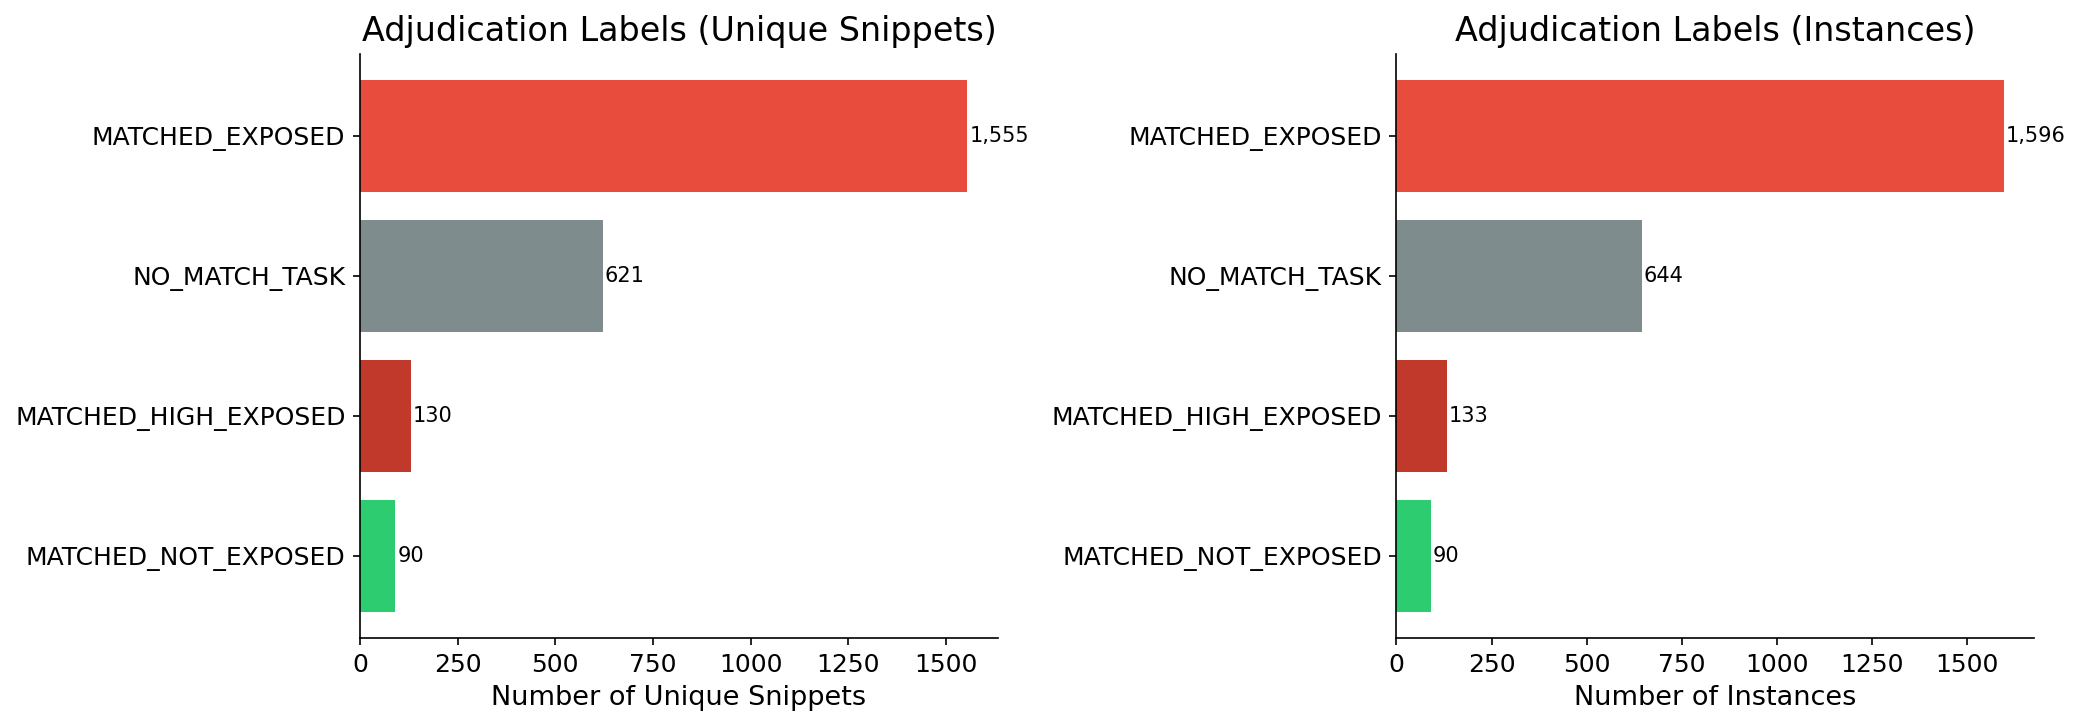

In [23]:
# =============================================================================
# G.1 ADJUDICATION LABEL DISTRIBUTION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unique snippets
ax = axes[0]
label_counts = adjudicated_unique['adjudication_label'].value_counts()
colors_map = {
    'MATCHED_HIGH_EXPOSED': '#C0392B',
    'MATCHED_EXPOSED': '#E74C3C',
    'MATCHED_NOT_EXPOSED': '#2ECC71',
    'MATCHED_UNKNOWN': '#95A5A6',
    'NO_MATCH_TASK': '#7F8C8D',
}
colors = [colors_map.get(l, '#BDC3C7') for l in label_counts.index]

bars = ax.barh(range(len(label_counts)), label_counts.values, color=colors)
ax.set_yticks(range(len(label_counts)))
ax.set_yticklabels(label_counts.index)
ax.set_xlabel('Number of Unique Snippets')
ax.set_title('Adjudication Labels (Unique Snippets)')

for bar, val in zip(bars, label_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)

ax.invert_yaxis()

# Instances (occurrence-weighted)
ax = axes[1]
instance_counts = adjudicated_instances['adjudication_label'].value_counts()
colors = [colors_map.get(l, '#BDC3C7') for l in instance_counts.index]

bars = ax.barh(range(len(instance_counts)), instance_counts.values, color=colors)
ax.set_yticks(range(len(instance_counts)))
ax.set_yticklabels(instance_counts.index)
ax.set_xlabel('Number of Instances')
ax.set_title('Adjudication Labels (Instances)')

for bar, val in zip(bars, instance_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_adjudication_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

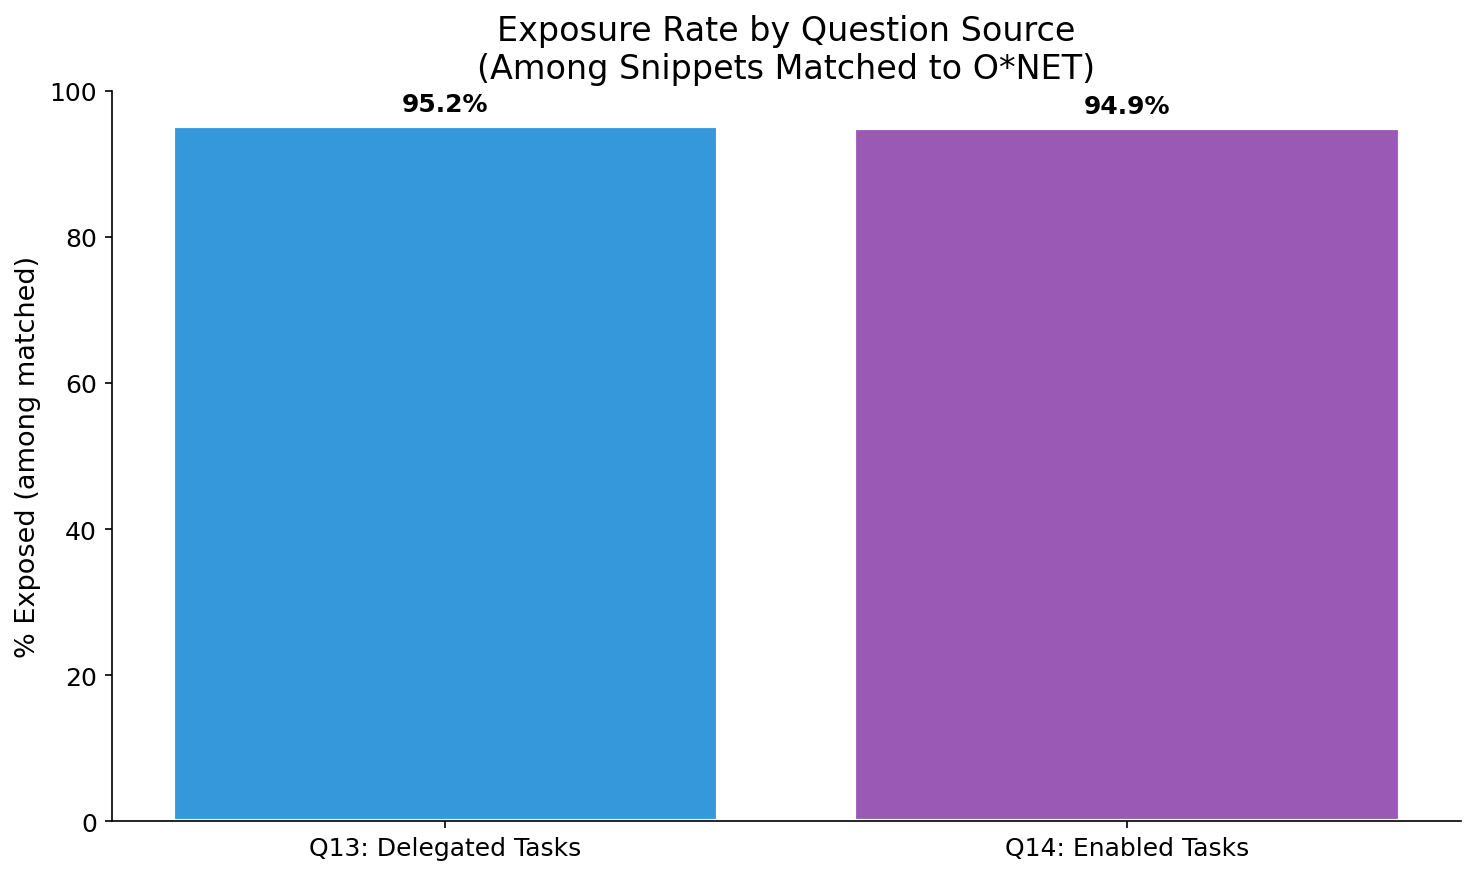

In [24]:
# =============================================================================
# G.2 EXPOSURE RATE BY SOURCE (Q13 vs Q14)
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Calculate rates among matched
matched_instances = adjudicated_instances[adjudicated_instances['is_matched']]
source_rates = matched_instances.groupby('source')['is_exposed'].mean() * 100

x = range(len(source_rates))
labels = ['Q13: Delegated Tasks', 'Q14: Enabled Tasks']
bars = ax.bar(x, source_rates.values, color=['#3498DB', '#9B59B6'], edgecolor='white', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('% Exposed (among matched)')
ax.set_title('Exposure Rate by Question Source\n(Among Snippets Matched to O*NET)')
ax.set_ylim(0, 100)

for bar, val in zip(bars, source_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_exposure_by_source.png", dpi=150, bbox_inches='tight')
plt.show()

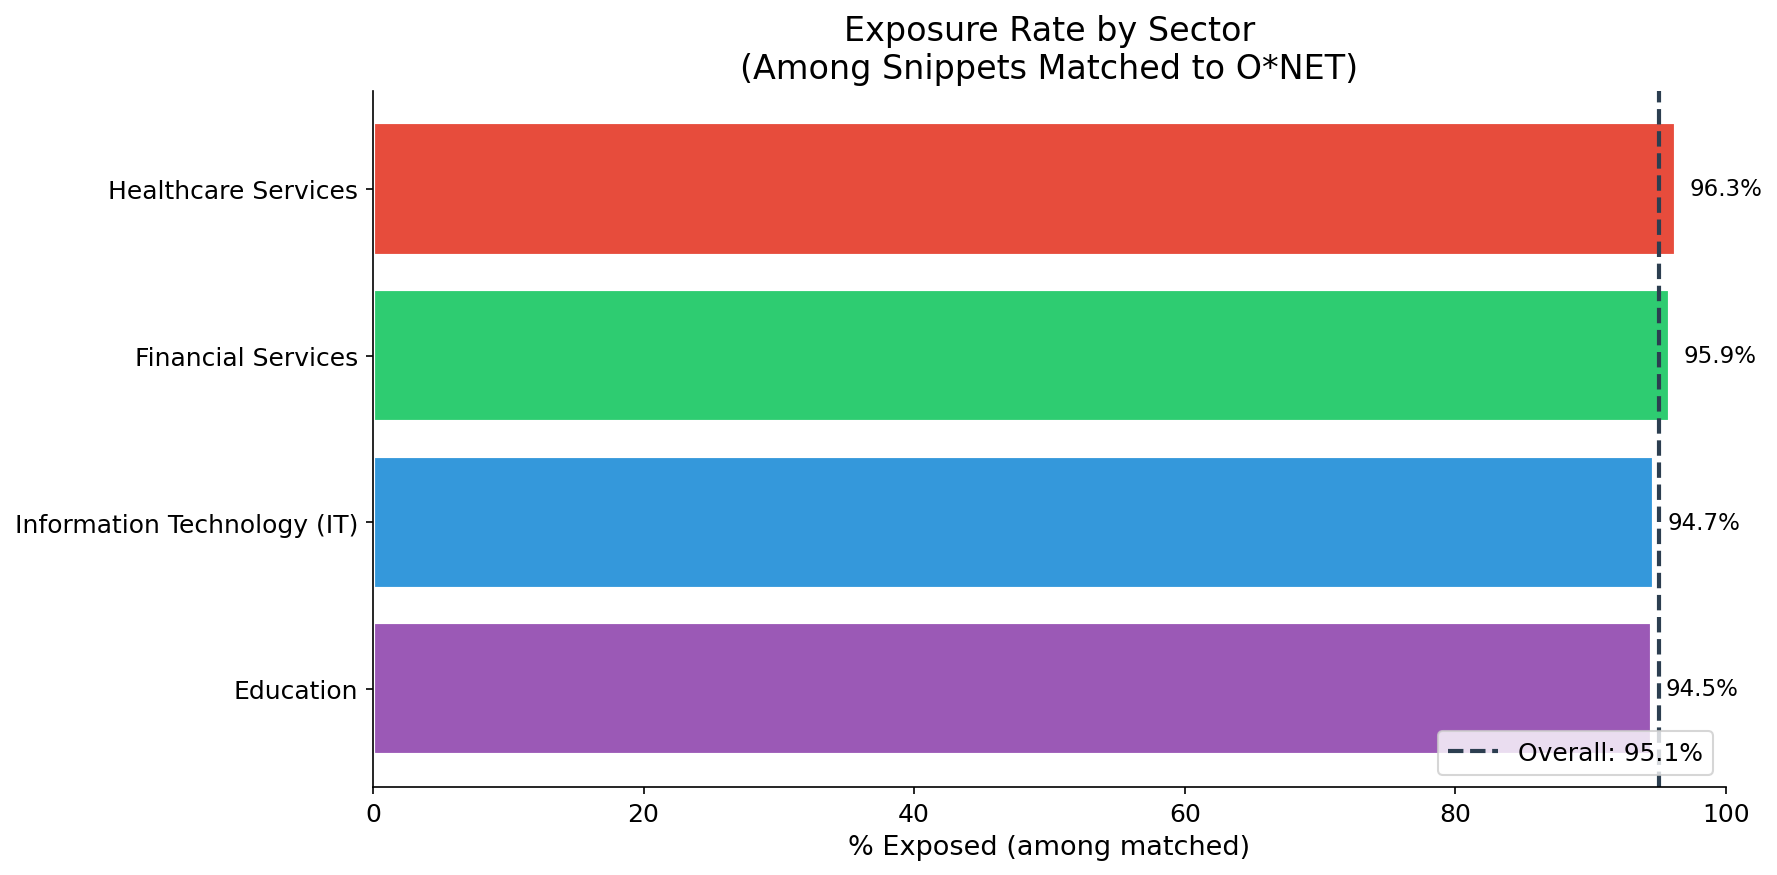

In [25]:
# =============================================================================
# G.3 EXPOSURE RATE BY SECTOR
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Calculate rates among matched by sector
sector_rates = matched_instances.groupby('sector')['is_exposed'].mean() * 100
sector_rates = sector_rates.sort_values(ascending=True)

y = range(len(sector_rates))
colors = [SECTOR_COLORS.get(s, '#7F8C8D') for s in sector_rates.index]
bars = ax.barh(y, sector_rates.values, color=colors, edgecolor='white', linewidth=2)

ax.set_yticks(y)
ax.set_yticklabels(sector_rates.index)
ax.set_xlabel('% Exposed (among matched)')
ax.set_title('Exposure Rate by Sector\n(Among Snippets Matched to O*NET)')
ax.set_xlim(0, 100)

for bar, val in zip(bars, sector_rates.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=11)

# Add overall average line
overall_rate = matched_instances['is_exposed'].mean() * 100
ax.axvline(x=overall_rate, color='#2C3E50', linestyle='--', linewidth=2, label=f'Overall: {overall_rate:.1f}%')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_exposure_by_sector.png", dpi=150, bbox_inches='tight')
plt.show()

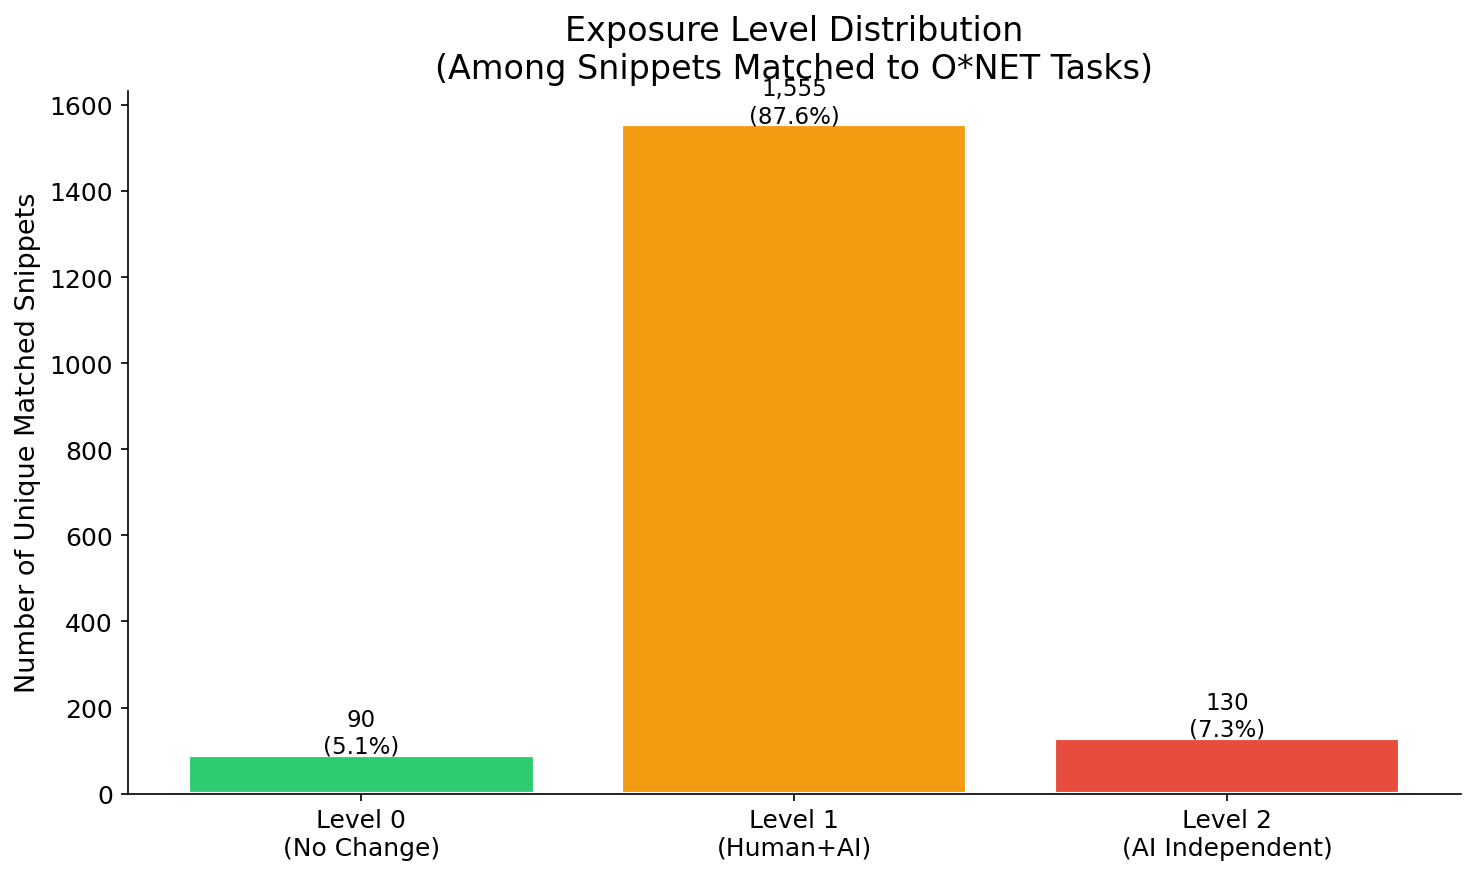

In [26]:
# =============================================================================
# G.4 EXPOSURE LEVEL DISTRIBUTION (among matched)
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Get exposure level distribution among matched
matched_unique = adjudicated_unique[adjudicated_unique['is_matched']]
level_dist = matched_unique['exposure_3level'].value_counts().sort_index()

labels = ['Level 0\n(No Change)', 'Level 1\n(Human+AI)', 'Level 2\n(AI Independent)']
colors = ['#2ECC71', '#F39C12', '#E74C3C']

bars = ax.bar(range(len(level_dist)), level_dist.values, color=colors, edgecolor='white', linewidth=2)
ax.set_xticks(range(len(level_dist)))
ax.set_xticklabels(labels)
ax.set_ylabel('Number of Unique Matched Snippets')
ax.set_title('Exposure Level Distribution\n(Among Snippets Matched to O*NET Tasks)')

for bar, val in zip(bars, level_dist.values):
    pct = val / len(matched_unique) * 100
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_exposure_level_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

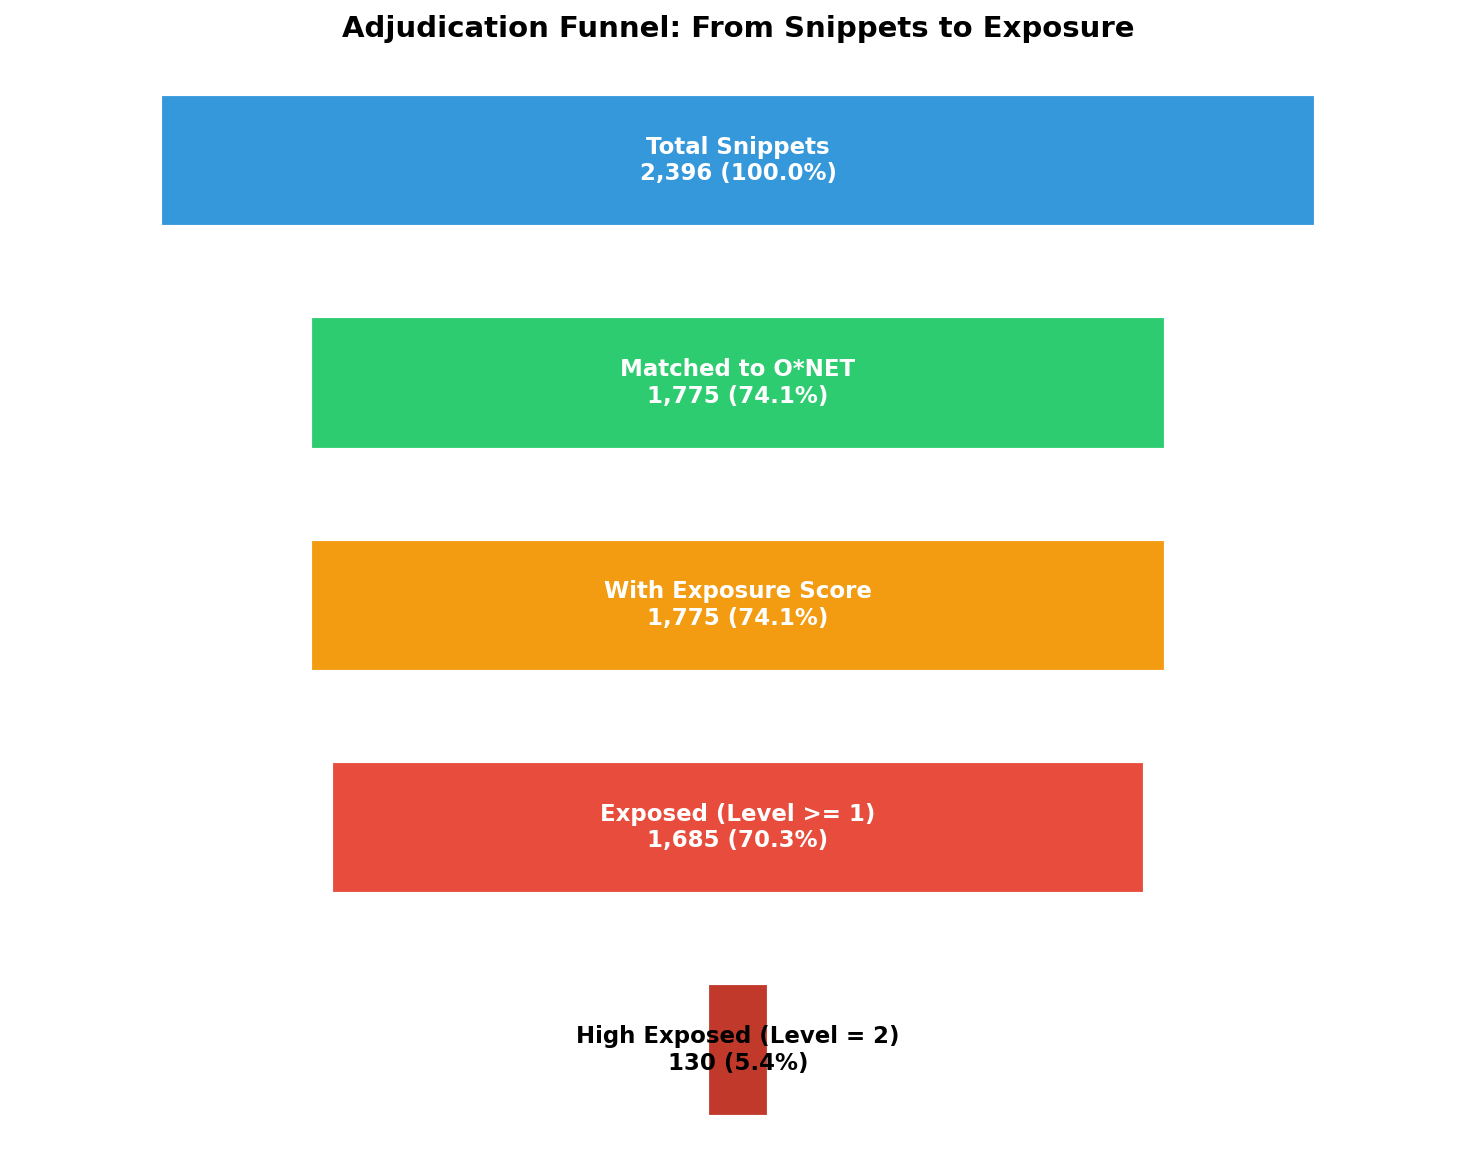

In [27]:
# =============================================================================
# G.5 FUNNEL VISUALIZATION
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Build funnel stages
n_total = len(adjudicated_unique)
n_matched = adjudicated_unique['is_matched'].sum()
n_with_score = adjudicated_unique['exposure_3level'].notna().sum()
n_exposed = adjudicated_unique['is_exposed'].sum()
n_high = adjudicated_unique['is_high_exposed'].sum()

stages = [
    ('Total Snippets', n_total, '#3498DB'),
    ('Matched to O*NET', n_matched, '#2ECC71'),
    ('With Exposure Score', n_with_score, '#F39C12'),
    ('Exposed (Level >= 1)', n_exposed, '#E74C3C'),
    ('High Exposed (Level = 2)', n_high, '#C0392B'),
]

y_positions = range(len(stages))
widths = [s[1] for s in stages]
max_width = max(widths)

for i, (label, count, color) in enumerate(stages):
    width = count / max_width * 0.8
    left = (1 - width) / 2
    ax.barh(i, width, left=left, height=0.6, color=color, edgecolor='white', linewidth=2)
    
    pct = count / n_total * 100
    ax.text(0.5, i, f'{label}\n{count:,} ({pct:.1f}%)', ha='center', va='center', 
            fontsize=11, fontweight='bold', color='white' if count > n_total * 0.3 else 'black')

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, len(stages) - 0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('Adjudication Funnel: From Snippets to Exposure', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_adjudication_funnel.png", dpi=150, bbox_inches='tight')
plt.show()

## H. Quality Audit Pack

In [28]:
# =============================================================================
# H.1 GENERATE AUDIT SAMPLES
# =============================================================================

np.random.seed(42)

audit_pack = {}

# 1. High-exposed matched (should check these are genuinely AI-automatable)
high_exposed = adjudicated_unique[adjudicated_unique['is_high_exposed']]
if len(high_exposed) >= 20:
    audit_pack['high_exposed_sample'] = high_exposed.sample(20)[[
        'task_key', 'example_snippet', 'selected_task_text', 'exposure_3level', 'occurrences'
    ]]
elif len(high_exposed) > 0:
    audit_pack['high_exposed_sample'] = high_exposed[[
        'task_key', 'example_snippet', 'selected_task_text', 'exposure_3level', 'occurrences'
    ]]

# 2. Not-exposed matched (should check if exposure score is wrong)
if len(not_exposed) >= 20:
    audit_pack['not_exposed_sample'] = not_exposed.sample(20)[[
        'task_key', 'example_snippet', 'selected_task_text', 'exposure_3level', 'occurrences'
    ]]
elif len(not_exposed) > 0:
    audit_pack['not_exposed_sample'] = not_exposed[[
        'task_key', 'example_snippet', 'selected_task_text', 'exposure_3level', 'occurrences'
    ]]

# 3. No-match high-occurrence (should check if these are real gaps)
if len(no_match) >= 20:
    audit_pack['no_match_sample'] = no_match.nlargest(20, 'occurrences')[[
        'task_key', 'example_snippet', 'top1_similarity', 'occurrences', 'sources'
    ]]

# Print and save
for name, df in audit_pack.items():
    print(f"\n{name.upper()} ({len(df)} examples):")
    print("-" * 60)
    for i, row in df.head(5).iterrows():
        print(f"  Snippet: {row['example_snippet'][:50]}...")
        if 'selected_task_text' in row and pd.notna(row['selected_task_text']):
            print(f"  -> O*NET: {row['selected_task_text'][:50]}...")
        if 'exposure_3level' in row:
            print(f"     Exposure: {row['exposure_3level']}")
    
    df.to_csv(OUTPUT_DIR / f"audit_{name}.csv", index=False)

print(f"\nAudit files saved to {OUTPUT_DIR}")


HIGH_EXPOSED_SAMPLE (20 examples):
------------------------------------------------------------
  Snippet: Summarizing long documents or articles...
  -> O*NET: Compose explanatory summaries of contents of books...
     Exposure: 2.0
  Snippet: Search and summarizing of stuff...
  -> O*NET: Compose explanatory summaries of contents of books...
     Exposure: 2.0
  Snippet: It has helped me do some paperwork...
  -> O*NET: Document activities and record information, such a...
     Exposure: 2.0
  Snippet: tasks like creating excel sheets which would slow ...
  -> O*NET: Perform various data entry or word processing task...
     Exposure: 2.0
  Snippet: Data entry or analysis...
  -> O*NET: Enter data into computers for use in analyses or r...
     Exposure: 2.0

NOT_EXPOSED_SAMPLE (20 examples):
------------------------------------------------------------
  Snippet: AI tools have made integration easy...
  -> O*NET: Integrate software or hardware components, using c...
     Exposure: 0

## I. Toplines and Summary

In [29]:
# =============================================================================
# I.1 GENERATE TOPLINES.TXT
# =============================================================================

toplines = []
toplines.append("EXPOSURE ADJUDICATION - TOPLINES")
toplines.append("=" * 60)
toplines.append(f"Generated: {datetime.now().isoformat()}")
toplines.append(f"Exposure threshold: level >= {EXPOSURE_THRESHOLD_PRIMARY} = exposed")
toplines.append("")

# Coverage
toplines.append("COVERAGE")
toplines.append(f"  Total unique snippets: {len(adjudicated_unique):,}")
toplines.append(f"  Matched to O*NET: {n_matched:,} ({n_matched/len(adjudicated_unique)*100:.1f}%)")
toplines.append(f"  Not matched: {len(adjudicated_unique) - n_matched:,}")
toplines.append("")

# Exposure summary
toplines.append("EXPOSURE SUMMARY (among matched snippets)")
matched_df = adjudicated_unique[adjudicated_unique['is_matched']]
toplines.append(f"  Matched snippets: {len(matched_df):,}")
toplines.append(f"  Exposed (level >= 1): {matched_df['is_exposed'].sum():,} ({matched_df['is_exposed'].mean()*100:.1f}%)")
toplines.append(f"  High exposed (level = 2): {matched_df['is_high_exposed'].sum():,} ({matched_df['is_high_exposed'].mean()*100:.1f}%)")
toplines.append(f"  Not exposed (level = 0): {(~matched_df['is_exposed']).sum():,} ({(~matched_df['is_exposed']).mean()*100:.1f}%)")
toplines.append("")

# By source
toplines.append("EXPOSURE BY SOURCE (among matched instances)")
for source in ['Q13_delegated', 'Q14_enabled']:
    source_matched = adjudicated_instances[(adjudicated_instances['source'] == source) & (adjudicated_instances['is_matched'])]
    if len(source_matched) > 0:
        exp_rate = source_matched['is_exposed'].mean() * 100
        toplines.append(f"  {source}: {exp_rate:.1f}% exposed (n={len(source_matched):,})")
toplines.append("")

# By sector
toplines.append("EXPOSURE BY SECTOR (among matched instances)")
for sector in sorted(adjudicated_instances['sector'].dropna().unique()):
    sector_matched = adjudicated_instances[(adjudicated_instances['sector'] == sector) & (adjudicated_instances['is_matched'])]
    if len(sector_matched) > 0:
        exp_rate = sector_matched['is_exposed'].mean() * 100
        toplines.append(f"  {sector}: {exp_rate:.1f}% exposed (n={len(sector_matched):,})")
toplines.append("")

# Adjudication labels
toplines.append("ADJUDICATION LABELS")
for label, count in adjudicated_unique['adjudication_label'].value_counts().items():
    pct = count / len(adjudicated_unique) * 100
    toplines.append(f"  {label}: {count:,} ({pct:.1f}%)")
toplines.append("")

# Top 5 exposed tasks
toplines.append("TOP 5 EXPOSED O*NET TASKS (by occurrences)")
if len(exposed_df) > 0:
    top5_exposed = exposed_df.groupby('selected_task_text')['occurrences'].sum().nlargest(5)
    for task, count in top5_exposed.items():
        toplines.append(f"  ({count}x) {task[:55]}...")
toplines.append("")

# Top 5 gaps
toplines.append("TOP 5 TAXONOMY GAPS (no O*NET match)")
for i, row in no_match.nlargest(5, 'occurrences').iterrows():
    toplines.append(f"  ({row['occurrences']}x) {row['task_key'][:55]}...")
toplines.append("")

# Charts generated
toplines.append("OUTPUT FILES")
for f in sorted(OUTPUT_DIR.glob("*")):
    toplines.append(f"  {f.name}")

# Write
toplines_path = OUTPUT_DIR / "toplines.txt"
with open(toplines_path, 'w') as f:
    f.write('\n'.join(toplines))

print('\n'.join(toplines))
print(f"\nSaved: {toplines_path}")

EXPOSURE ADJUDICATION - TOPLINES
Generated: 2026-02-12T15:51:22.028990
Exposure threshold: level >= 1 = exposed

COVERAGE
  Total unique snippets: 2,396
  Matched to O*NET: 1,775 (74.1%)
  Not matched: 621

EXPOSURE SUMMARY (among matched snippets)
  Matched snippets: 1,775
  Exposed (level >= 1): 1,685 (94.9%)
  High exposed (level = 2): 130 (7.3%)
  Not exposed (level = 0): 90 (5.1%)

EXPOSURE BY SOURCE (among matched instances)
  Q13_delegated: 95.2% exposed (n=1,033)
  Q14_enabled: 94.9% exposed (n=786)

EXPOSURE BY SECTOR (among matched instances)
  Education: 94.5% exposed (n=238)
  Financial Services: 95.9% exposed (n=342)
  Healthcare Services: 96.3% exposed (n=189)
  Information Technology (IT): 94.7% exposed (n=1,050)

ADJUDICATION LABELS
  MATCHED_EXPOSED: 1,555 (64.9%)
  NO_MATCH_TASK: 621 (25.9%)
  MATCHED_HIGH_EXPOSED: 130 (5.4%)
  MATCHED_NOT_EXPOSED: 90 (3.8%)

TOP 5 EXPOSED O*NET TASKS (by occurrences)
  (33x) Type, format, proofread, and edit correspondence and ot...


## J. Mismatch Analysis: Matched but Not Exposed

Create a CSV of analytically important mismatches where workers report using AI for tasks
that the exposure scoring framework classifies as "not exposed" (level 0).

In [30]:
# =============================================================================
# J.1 CREATE "MATCHED BUT NOT EXPOSED" CSV
# =============================================================================

print("=" * 70)
print("STEP A: Creating Matched-But-Not-Exposed CSV")
print("=" * 70)

# Filter to MATCHED_NOT_EXPOSED with valid task ID
mismatch_df = adjudicated_instances[
    (adjudicated_instances['adjudication_label'] == 'MATCHED_NOT_EXPOSED') &
    (adjudicated_instances['selected_statement_id'].notna())
].copy()

print(f"\nFiltered to MATCHED_NOT_EXPOSED with valid task ID: {len(mismatch_df)} rows")

# Select and rename columns for output
mismatch_cols = [
    'snippet_id',
    'respondent_id',
    'sector',
    'role',
    'source',
    'snippet',
    'selected_statement_id',
    'selected_task_text',
    'exposure_3level',
    'top1_similarity'
]

# Check which columns exist
available_cols = [c for c in mismatch_cols if c in mismatch_df.columns]
missing_cols = [c for c in mismatch_cols if c not in mismatch_df.columns]
if missing_cols:
    print(f"Note: Missing columns (will skip): {missing_cols}")

mismatch_export = mismatch_df[available_cols].copy()

# Rename columns to match spec
rename_map = {
    'source': 'question_source',
    'snippet': 'snippet_text',
    'selected_statement_id': 'final_task_id',
    'selected_task_text': 'final_task_description',
    'exposure_3level': 'exposure_score',
    'top1_similarity': 'match_similarity'
}
mismatch_export = mismatch_export.rename(columns=rename_map)

# Sort by question_source (Q13 first, Q14 second), then descending match_similarity
source_order = {'Q13_delegated': 0, 'Q14_enabled': 1}
mismatch_export['_sort_source'] = mismatch_export['question_source'].map(source_order)
mismatch_export = mismatch_export.sort_values(
    by=['_sort_source', 'match_similarity'],
    ascending=[True, False]
).drop(columns=['_sort_source'])

# Save CSV
mismatch_csv_path = OUTPUT_DIR / "survey_tasks_matched_but_not_exposed.csv"
mismatch_export.to_csv(mismatch_csv_path, index=False)

# Report statistics
n_mismatch = len(mismatch_export)
n_all_snippets = len(adjudicated_instances)
n_matched_snippets = adjudicated_instances['is_matched'].sum()

print(f"\n{'=' * 50}")
print(f"MISMATCH CSV SUMMARY")
print(f"{'=' * 50}")
print(f"Rows written: {n_mismatch:,}")
print(f"Share of all snippets: {n_mismatch/n_all_snippets*100:.2f}% ({n_mismatch:,}/{n_all_snippets:,})")
print(f"Share of matched snippets: {n_mismatch/n_matched_snippets*100:.2f}% ({n_mismatch:,}/{n_matched_snippets:,})")
print(f"\nSaved: {mismatch_csv_path}")

# Breakdown by question source
print(f"\nBreakdown by question source:")
for source in ['Q13_delegated', 'Q14_enabled']:
    n_source = (mismatch_export['question_source'] == source).sum()
    pct = n_source/n_mismatch*100 if n_mismatch > 0 else 0
    print(f"  {source}: {n_source:,} ({pct:.1f}%)")

STEP A: Creating Matched-But-Not-Exposed CSV

Filtered to MATCHED_NOT_EXPOSED with valid task ID: 90 rows

MISMATCH CSV SUMMARY
Rows written: 90
Share of all snippets: 3.65% (90/2,463)
Share of matched snippets: 4.95% (90/1,819)

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/adjudication/survey_tasks_matched_but_not_exposed.csv

Breakdown by question source:
  Q13_delegated: 50 (55.6%)
  Q14_enabled: 40 (44.4%)


## K. Diagnostic Plots

Generate diagnostic visualizations for the adjudication results.

STEP B: Generating Diagnostic Plots


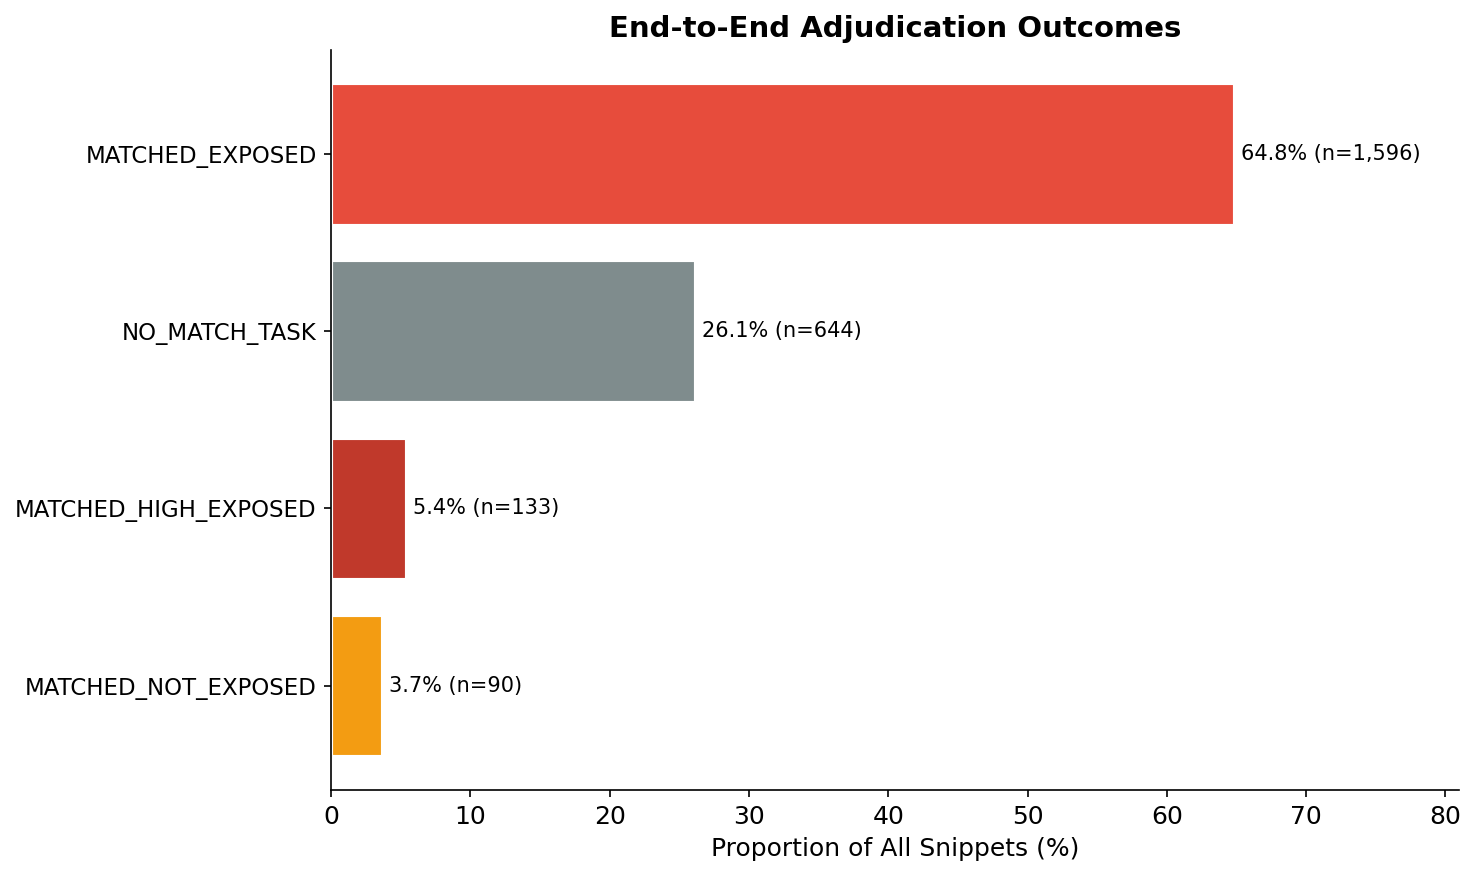

Plot 1 saved: fig_plot1_adjudication_outcomes.png


In [31]:
# =============================================================================
# K.1 PLOT 1: ADJUDICATION OUTCOME DISTRIBUTION
# =============================================================================

print("=" * 70)
print("STEP B: Generating Diagnostic Plots")
print("=" * 70)

fig, ax = plt.subplots(figsize=(10, 6))

# Count snippets by adjudication_label (proportions)
label_counts = adjudicated_instances['adjudication_label'].value_counts()
label_props = label_counts / len(adjudicated_instances) * 100

# Color mapping
colors_outcome = {
    'MATCHED_HIGH_EXPOSED': '#C0392B',
    'MATCHED_EXPOSED': '#E74C3C',
    'MATCHED_NOT_EXPOSED': '#F39C12',
    'MATCHED_UNKNOWN': '#95A5A6',
    'NO_MATCH_TASK': '#7F8C8D',
}
colors = [colors_outcome.get(l, '#BDC3C7') for l in label_props.index]

bars = ax.barh(range(len(label_props)), label_props.values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(label_props)))
ax.set_yticklabels(label_props.index, fontsize=11)
ax.set_xlabel('Proportion of All Snippets (%)', fontsize=12)
ax.set_title('End-to-End Adjudication Outcomes', fontsize=14, fontweight='bold')

# Add value labels
for bar, val, count in zip(bars, label_props.values, label_counts.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}% (n={count:,})', va='center', fontsize=10)

ax.invert_yaxis()
ax.set_xlim(0, max(label_props.values) * 1.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_plot1_adjudication_outcomes.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved: fig_plot1_adjudication_outcomes.png")

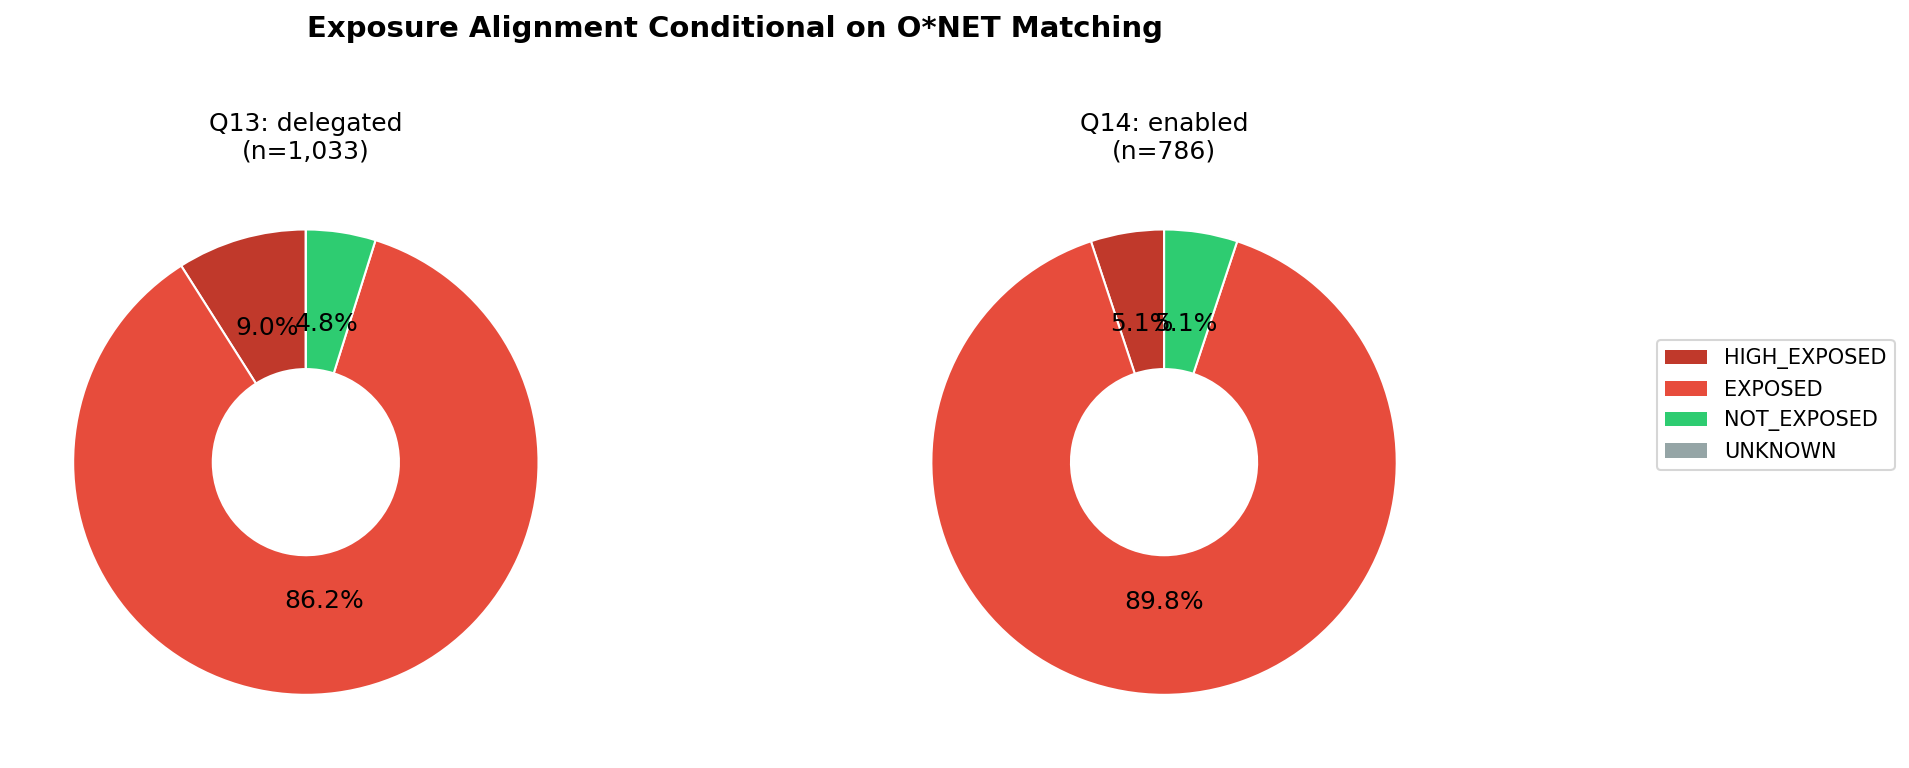

Plot 2 saved: fig_plot2_exposure_alignment_by_source.png


In [32]:
# =============================================================================
# K.2 PLOT 2: EXPOSURE ALIGNMENT AMONG MATCHED TASKS (by Q13 vs Q14)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

matched_only = adjudicated_instances[adjudicated_instances['is_matched']].copy()

# Create exposed_flag column
def get_exposed_flag(row):
    if row['adjudication_label'] == 'MATCHED_HIGH_EXPOSED':
        return 'HIGH_EXPOSED'
    elif row['adjudication_label'] == 'MATCHED_EXPOSED':
        return 'EXPOSED'
    elif row['adjudication_label'] == 'MATCHED_NOT_EXPOSED':
        return 'NOT_EXPOSED'
    else:
        return 'UNKNOWN'

matched_only['exposed_flag'] = matched_only.apply(get_exposed_flag, axis=1)

flag_colors = {
    'HIGH_EXPOSED': '#C0392B',
    'EXPOSED': '#E74C3C',
    'NOT_EXPOSED': '#2ECC71',
    'UNKNOWN': '#95A5A6'
}
flag_order = ['HIGH_EXPOSED', 'EXPOSED', 'NOT_EXPOSED', 'UNKNOWN']

for idx, source in enumerate(['Q13_delegated', 'Q14_enabled']):
    ax = axes[idx]
    source_df = matched_only[matched_only['source'] == source]

    if len(source_df) > 0:
        flag_counts = source_df['exposed_flag'].value_counts()
        # Ensure all flags are present
        for flag in flag_order:
            if flag not in flag_counts.index:
                flag_counts[flag] = 0
        flag_counts = flag_counts[flag_order]
        flag_props = flag_counts / len(source_df) * 100

        colors = [flag_colors[f] for f in flag_order]
        wedges, texts, autotexts = ax.pie(
            flag_props.values,
            colors=colors,
            autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
            startangle=90,
            wedgeprops=dict(width=0.6, edgecolor='white')
        )

        ax.set_title(f'{source.replace("_", ": ")}\n(n={len(source_df):,})', fontsize=12)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(f'{source}')

# Add legend
fig.legend(
    [plt.Rectangle((0,0),1,1, facecolor=flag_colors[f]) for f in flag_order],
    flag_order,
    loc='center right',
    bbox_to_anchor=(1.15, 0.5),
    fontsize=10
)

fig.suptitle('Exposure Alignment Conditional on O*NET Matching', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_plot2_exposure_alignment_by_source.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved: fig_plot2_exposure_alignment_by_source.png")

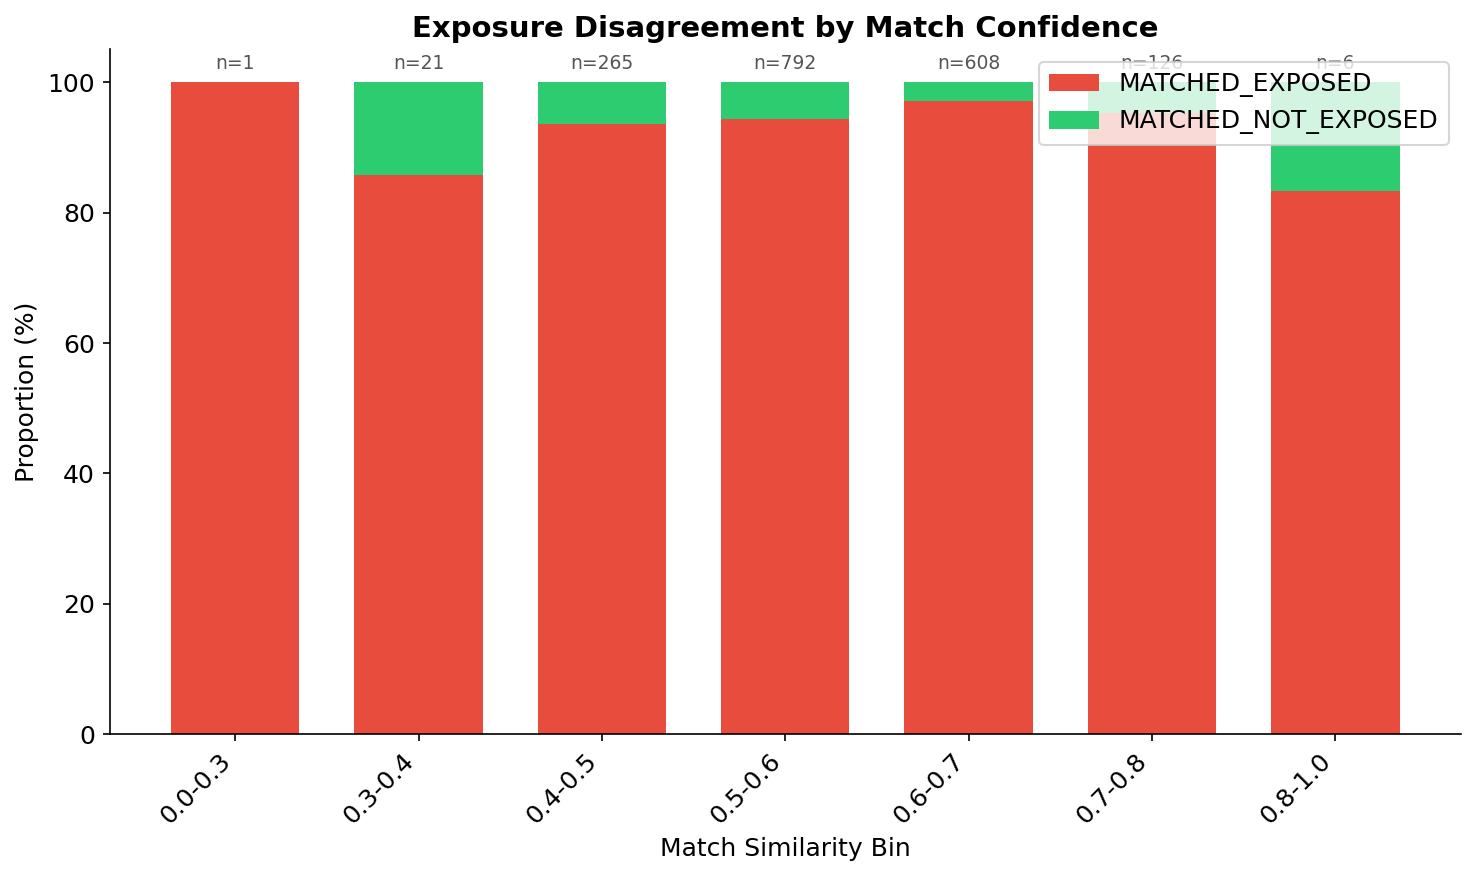

Plot 3 saved: fig_plot3_exposure_by_match_confidence.png


In [33]:
# =============================================================================
# K.3 PLOT 3: MATCH QUALITY VS EXPOSURE DISAGREEMENT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Restrict to matched with valid similarity
matched_with_sim = matched_only[matched_only['top1_similarity'].notna()].copy()

# Bin match_similarity
bins = [0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
bin_labels = ['0.0-0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-1.0']
matched_with_sim['sim_bin'] = pd.cut(matched_with_sim['top1_similarity'], bins=bins, labels=bin_labels)

# Calculate proportion NOT_EXPOSED within each bin
bin_stats = matched_with_sim.groupby('sim_bin').agg({
    'adjudication_label': [
        lambda x: (x == 'MATCHED_NOT_EXPOSED').sum(),
        lambda x: x.isin(['MATCHED_EXPOSED', 'MATCHED_HIGH_EXPOSED']).sum(),
        'count'
    ]
}).reset_index()
bin_stats.columns = ['sim_bin', 'not_exposed', 'exposed', 'total']
bin_stats['pct_not_exposed'] = bin_stats['not_exposed'] / bin_stats['total'] * 100
bin_stats['pct_exposed'] = bin_stats['exposed'] / bin_stats['total'] * 100

# Stacked bar chart
x = range(len(bin_stats))
width = 0.7

bars_exposed = ax.bar(x, bin_stats['pct_exposed'], width, label='MATCHED_EXPOSED', color='#E74C3C')
bars_not_exposed = ax.bar(x, bin_stats['pct_not_exposed'], width, bottom=bin_stats['pct_exposed'],
                          label='MATCHED_NOT_EXPOSED', color='#2ECC71')

ax.set_xticks(x)
ax.set_xticklabels(bin_stats['sim_bin'], rotation=45, ha='right')
ax.set_xlabel('Match Similarity Bin', fontsize=12)
ax.set_ylabel('Proportion (%)', fontsize=12)
ax.set_title('Exposure Disagreement by Match Confidence', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 105)

# Add count labels on top
for i, (idx, row) in enumerate(bin_stats.iterrows()):
    ax.text(i, 102, f'n={int(row["total"])}', ha='center', fontsize=9, color='#555')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_plot3_exposure_by_match_confidence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved: fig_plot3_exposure_by_match_confidence.png")

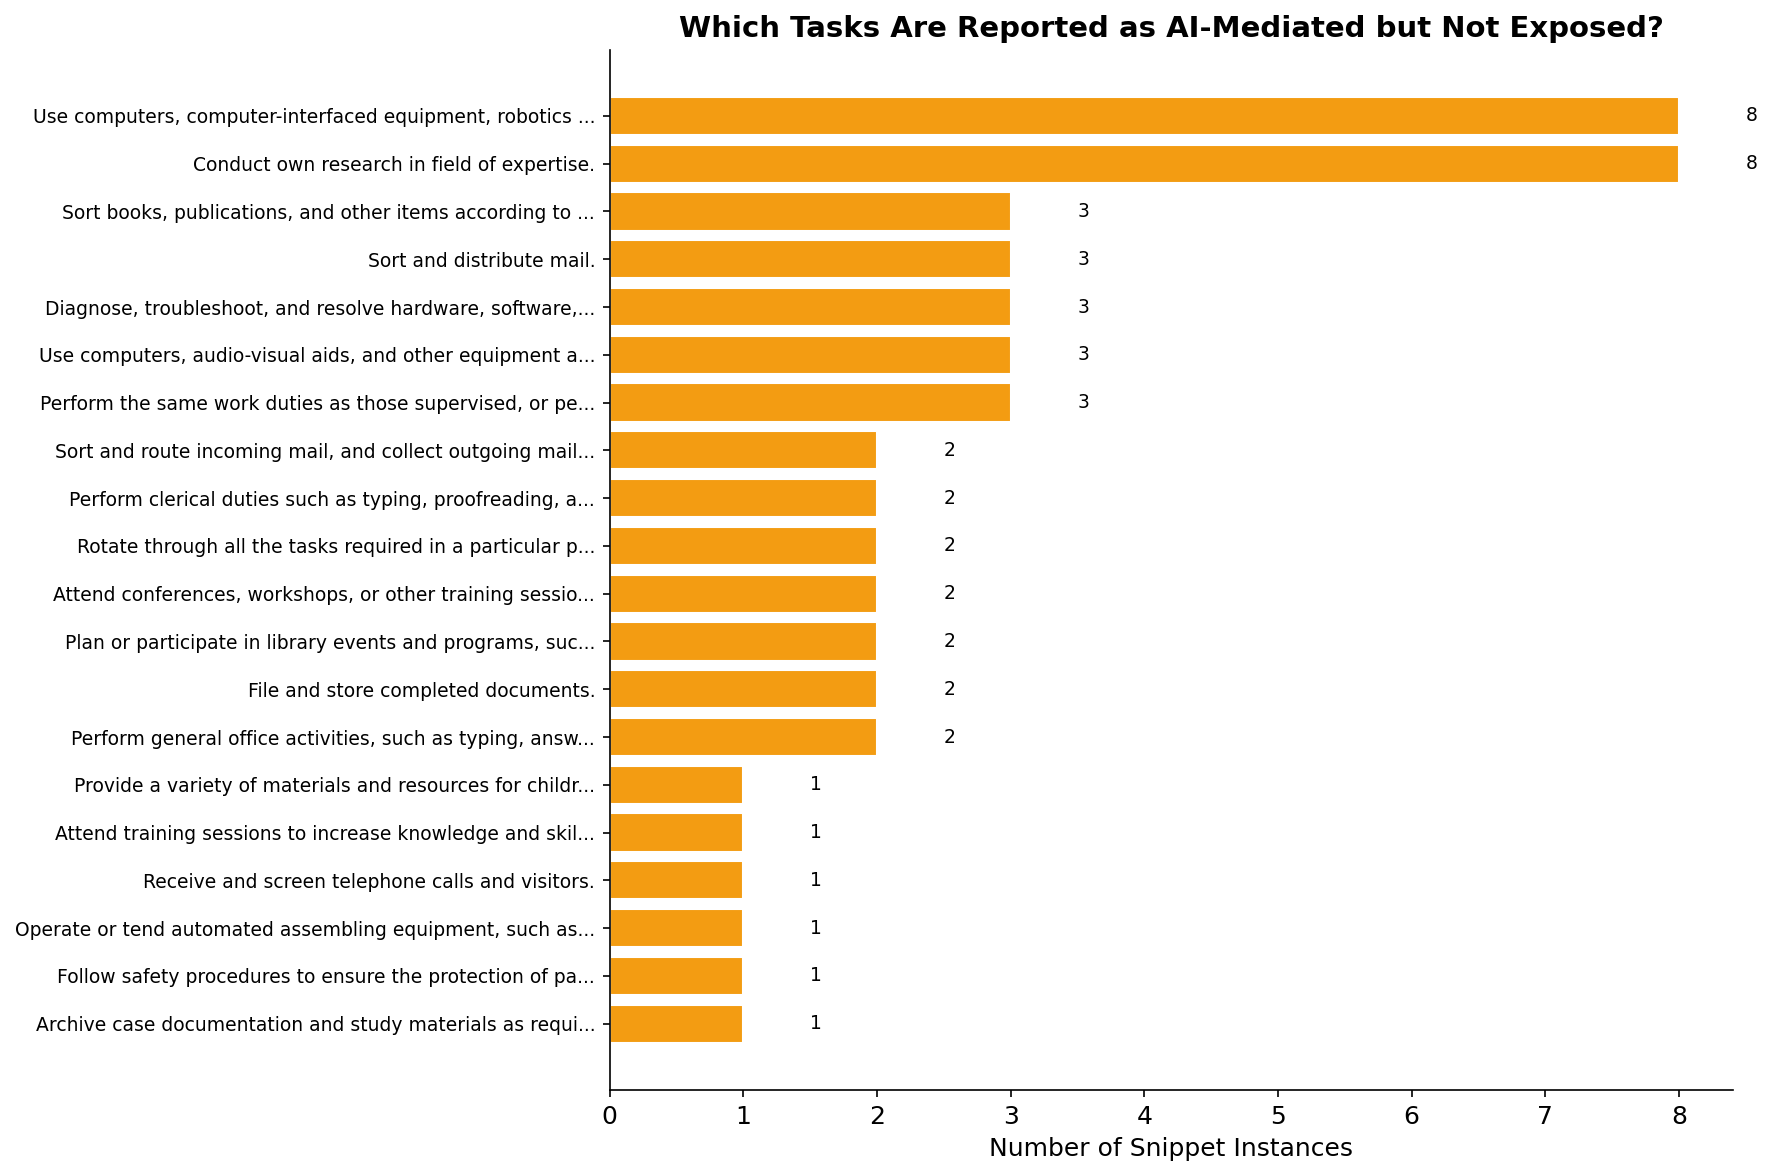

Plot 4 saved: fig_plot4_mismatch_task_families.png


In [34]:
# =============================================================================
# K.4 PLOT 4: TASK FAMILIES IN MISMATCHED CASES
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 8))

# Restrict to MATCHED_NOT_EXPOSED
mismatch_tasks = adjudicated_instances[
    adjudicated_instances['adjudication_label'] == 'MATCHED_NOT_EXPOSED'
].copy()

if len(mismatch_tasks) > 0 and 'selected_task_text' in mismatch_tasks.columns:
    # Group by task description and count
    task_counts = mismatch_tasks['selected_task_text'].value_counts().head(20)

    # Truncate long task descriptions for display
    task_labels = [t[:55] + '...' if len(str(t)) > 55 else str(t) for t in task_counts.index]

    y_pos = range(len(task_counts))
    bars = ax.barh(y_pos, task_counts.values, color='#F39C12', edgecolor='white', linewidth=1)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(task_labels, fontsize=9)
    ax.set_xlabel('Number of Snippet Instances', fontsize=12)
    ax.set_title('Which Tasks Are Reported as AI-Mediated but Not Exposed?', fontsize=14, fontweight='bold')

    # Add count labels
    for bar, val in zip(bars, task_counts.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=9)

    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, 'No mismatched tasks found', ha='center', va='center', fontsize=14)
    ax.set_title('Which Tasks Are Reported as AI-Mediated but Not Exposed?', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_plot4_mismatch_task_families.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved: fig_plot4_mismatch_task_families.png")


EXAMPLES OF SURVEY-EXPOSURE MISMATCH

Sampled 18 examples from MATCHED_NOT_EXPOSED:

----------------------------------------------------------------------------------------------------
Snippet: I now do Administrative tasks that was previously done by my...
  -> O*NET: Perform administrative tasks, such as answering te...
     Exposure: 0.0 | Sector: Information Technology (IT) | Role: Senior leadership / CTO / CIO / Director
----------------------------------------------------------------------------------------------------
Snippet: Typically to know more outright tools and equip me to carry ...
  -> O*NET: Attend conferences, workshops, or other training s...
     Exposure: 0.0 | Sector: Financial Services | Role: Relationship manager / Account manager
----------------------------------------------------------------------------------------------------
Snippet: Tech and Automation etc
  -> O*NET: Use computers, computer-interfaced equipment, robo...
     Exposure: 0.0 | Sector: Info

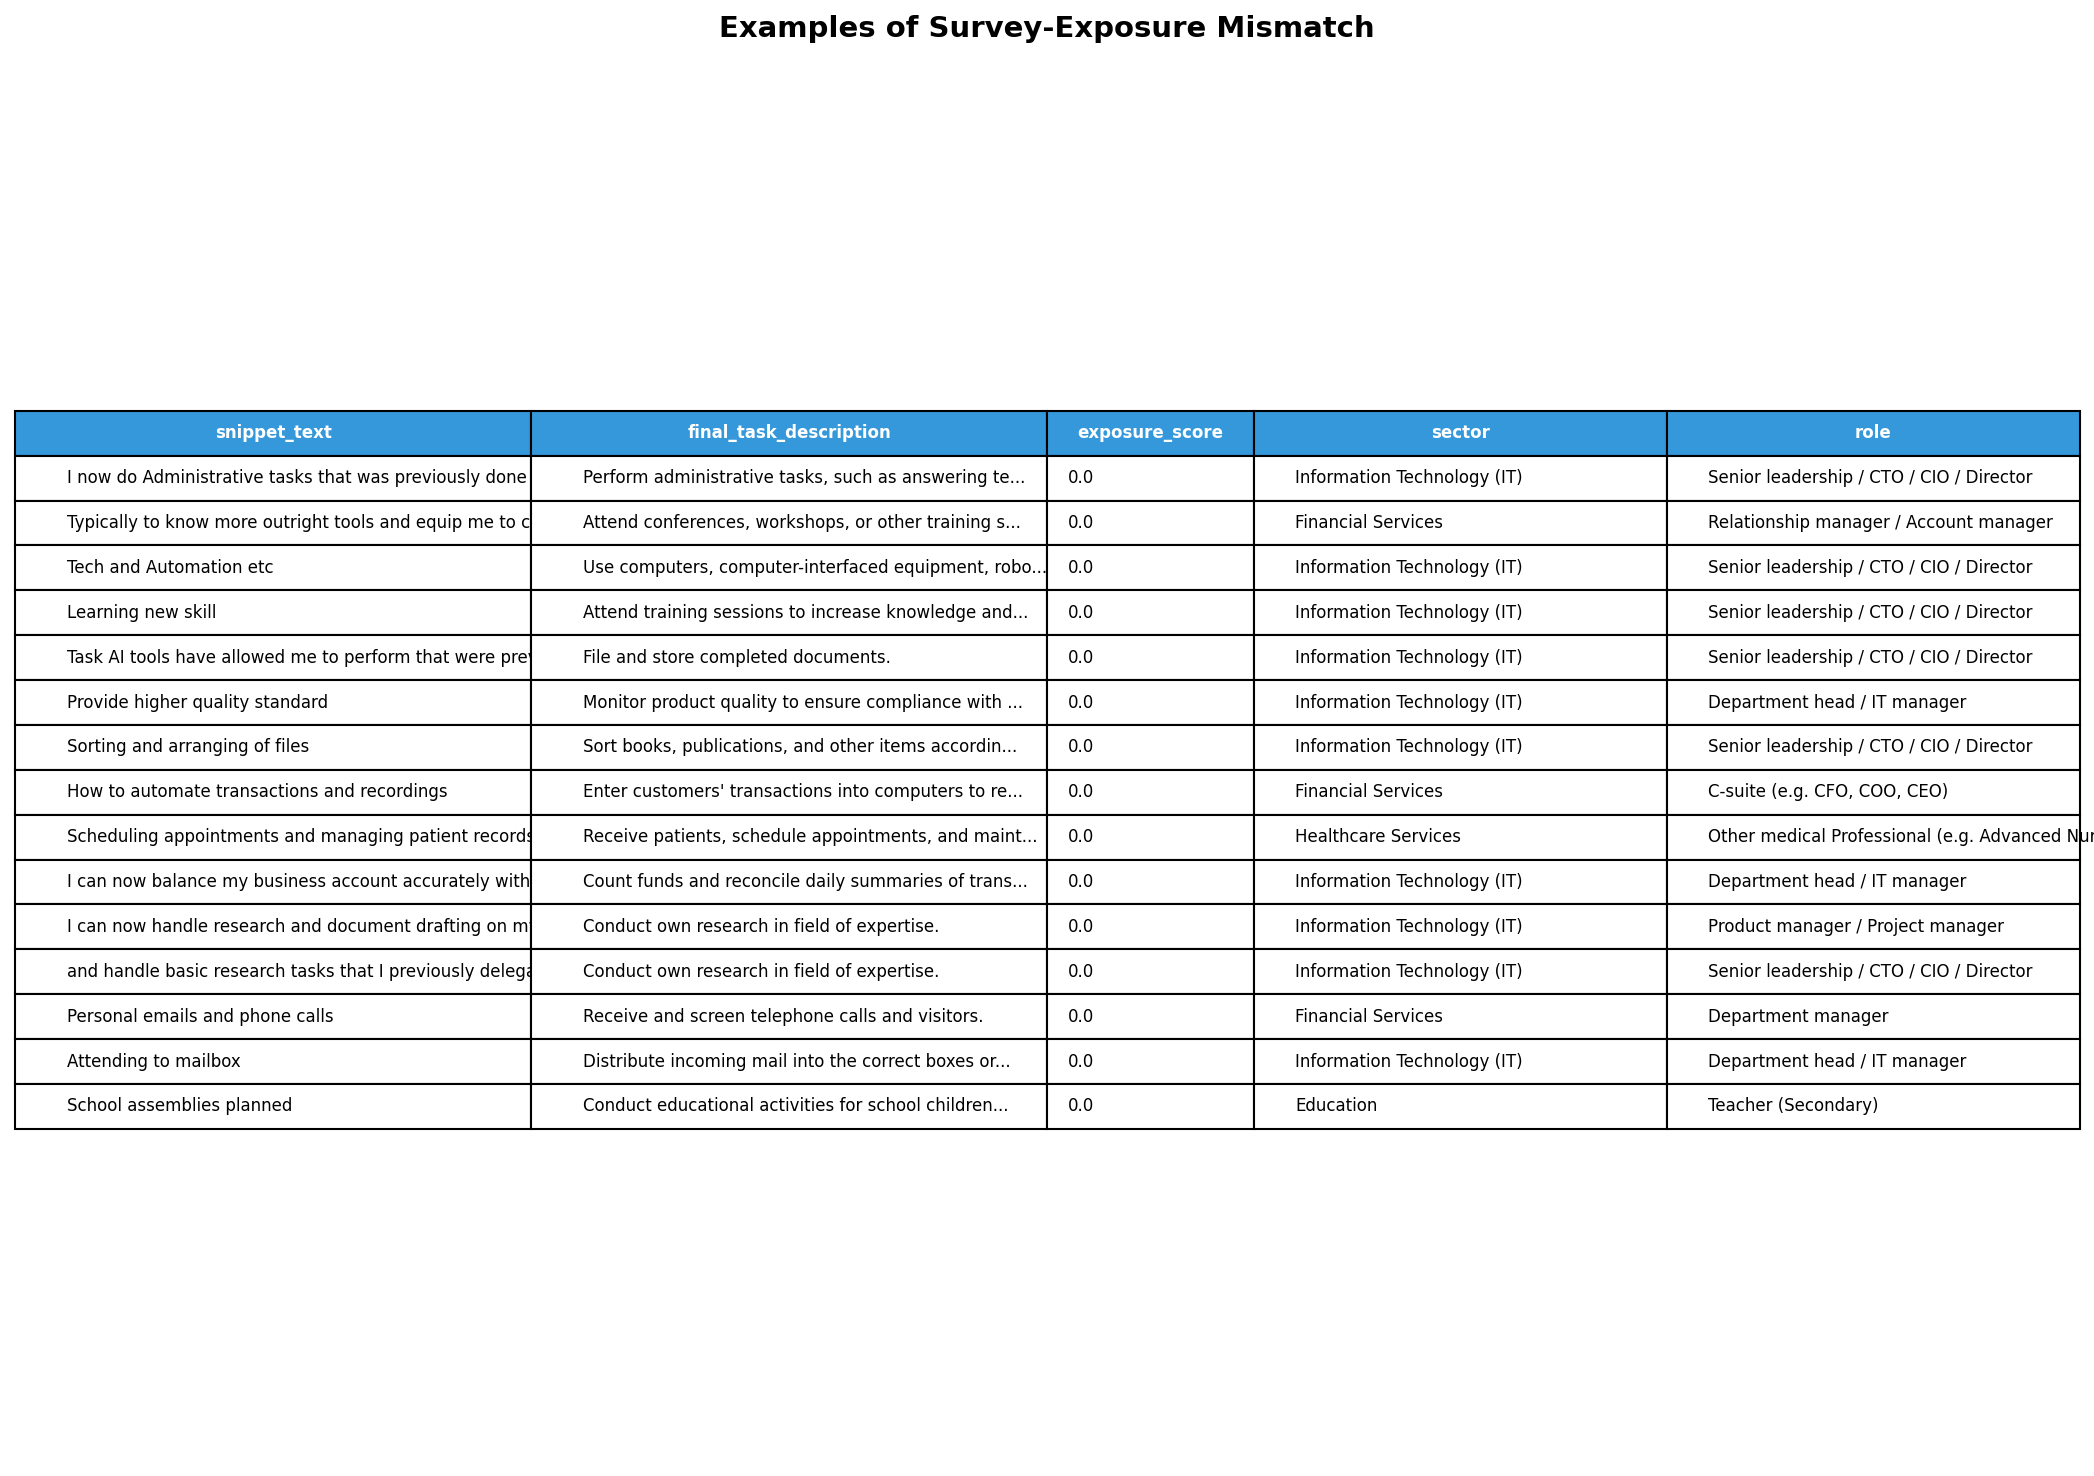

Plot 5 saved: fig_plot5_example_mismatch_table.png


In [35]:
# =============================================================================
# K.5 PLOT 5: EXAMPLE TABLE (SURVEY-EXPOSURE MISMATCH SAMPLES)
# =============================================================================

print("\n" + "=" * 70)
print("EXAMPLES OF SURVEY-EXPOSURE MISMATCH")
print("=" * 70)

np.random.seed(42)

# Sample 15-20 rows from MATCHED_NOT_EXPOSED
if len(mismatch_tasks) > 0:
    sample_size = min(18, len(mismatch_tasks))
    sample_df = mismatch_tasks.sample(sample_size)

    # Select display columns
    display_cols = ['snippet', 'selected_task_text', 'exposure_3level', 'sector', 'role']
    display_cols = [c for c in display_cols if c in sample_df.columns]

    example_table = sample_df[display_cols].copy()
    col_names = ['snippet_text', 'final_task_description', 'exposure_score', 'sector', 'role'][:len(display_cols)]
    example_table.columns = col_names

    # Truncate long text for display
    if 'snippet_text' in example_table.columns:
        example_table['snippet_text'] = example_table['snippet_text'].apply(
            lambda x: str(x)[:60] + '...' if len(str(x)) > 60 else str(x)
        )
    if 'final_task_description' in example_table.columns:
        example_table['final_task_description'] = example_table['final_task_description'].apply(
            lambda x: str(x)[:50] + '...' if pd.notna(x) and len(str(x)) > 50 else str(x)
        )

    # Save example table
    example_table.to_csv(OUTPUT_DIR / "example_mismatch_samples.csv", index=False)

    # Display as formatted table
    print(f"\nSampled {sample_size} examples from MATCHED_NOT_EXPOSED:\n")
    print("-" * 100)
    for i, row in example_table.iterrows():
        print(f"Snippet: {row.get('snippet_text', 'N/A')}")
        print(f"  -> O*NET: {row.get('final_task_description', 'N/A')}")
        print(f"     Exposure: {row.get('exposure_score', 'N/A')} | Sector: {row.get('sector', 'N/A')} | Role: {row.get('role', 'N/A')}")
        print("-" * 100)

    print(f"\nExample table saved: {OUTPUT_DIR / 'example_mismatch_samples.csv'}")

    # Also create a figure version of the table
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.axis('off')
    ax.set_title('Examples of Survey-Exposure Mismatch', fontsize=14, fontweight='bold', pad=20)

    # Create table
    table_data = example_table.head(15).values.tolist()
    table_cols = example_table.columns.tolist()

    table = ax.table(
        cellText=table_data,
        colLabels=table_cols,
        cellLoc='left',
        loc='center',
        colWidths=[0.25, 0.25, 0.1, 0.2, 0.2]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.2, 1.5)

    # Style header
    for i in range(len(table_cols)):
        table[(0, i)].set_facecolor('#3498DB')
        table[(0, i)].set_text_props(color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig_plot5_example_mismatch_table.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot 5 saved: fig_plot5_example_mismatch_table.png")
else:
    print("No MATCHED_NOT_EXPOSED rows to sample.")

## L. Summary Report

In [36]:
# =============================================================================
# L.1 MISMATCH ANALYSIS SUMMARY
# =============================================================================

print("\n" + "=" * 70)
print("STEP C: MISMATCH ANALYSIS SUMMARY")
print("=" * 70)

# Calculate key statistics for summary
n_total_snippets = len(adjudicated_instances)
n_matched = adjudicated_instances['is_matched'].sum()
n_mismatch = (adjudicated_instances['adjudication_label'] == 'MATCHED_NOT_EXPOSED').sum()

# Clustering by question source
mismatch_by_source = adjudicated_instances[
    adjudicated_instances['adjudication_label'] == 'MATCHED_NOT_EXPOSED'
]['source'].value_counts()
q13_mismatch = mismatch_by_source.get('Q13_delegated', 0)
q14_mismatch = mismatch_by_source.get('Q14_enabled', 0)

# Source totals for rate calculation
q13_matched = adjudicated_instances[
    (adjudicated_instances['source'] == 'Q13_delegated') &
    (adjudicated_instances['is_matched'])
].shape[0]
q14_matched = adjudicated_instances[
    (adjudicated_instances['source'] == 'Q14_enabled') &
    (adjudicated_instances['is_matched'])
].shape[0]

q13_mismatch_rate = q13_mismatch / q13_matched * 100 if q13_matched > 0 else 0
q14_mismatch_rate = q14_mismatch / q14_matched * 100 if q14_matched > 0 else 0

# Clustering by sector
mismatch_by_sector = adjudicated_instances[
    adjudicated_instances['adjudication_label'] == 'MATCHED_NOT_EXPOSED'
]['sector'].value_counts()

# Match confidence analysis
if 'top1_similarity' in mismatch_tasks.columns and len(mismatch_tasks) > 0:
    mismatch_sim_mean = mismatch_tasks['top1_similarity'].mean()
    mismatch_sim_median = mismatch_tasks['top1_similarity'].median()

    # Compare to exposed matches
    exposed_tasks = adjudicated_instances[
        adjudicated_instances['adjudication_label'].isin(['MATCHED_EXPOSED', 'MATCHED_HIGH_EXPOSED'])
    ]
    if len(exposed_tasks) > 0 and 'top1_similarity' in exposed_tasks.columns:
        exposed_sim_mean = exposed_tasks['top1_similarity'].mean()
        exposed_sim_median = exposed_tasks['top1_similarity'].median()
    else:
        exposed_sim_mean = exposed_sim_median = None
else:
    mismatch_sim_mean = mismatch_sim_median = None
    exposed_sim_mean = exposed_sim_median = None

# Top task types
if len(mismatch_tasks) > 0 and 'selected_task_text' in mismatch_tasks.columns:
    top_mismatch_tasks = mismatch_tasks['selected_task_text'].value_counts().head(3)
else:
    top_mismatch_tasks = pd.Series()

# Build summary text
summary_lines = []
summary_lines.append("MISMATCH ANALYSIS SUMMARY")
summary_lines.append("=" * 60)
summary_lines.append("")
summary_lines.append(f"Total mismatches (MATCHED_NOT_EXPOSED): {n_mismatch:,}")
summary_lines.append(f"  - Share of all snippets: {n_mismatch/n_total_snippets*100:.1f}%")
summary_lines.append(f"  - Share of matched snippets: {n_mismatch/n_matched*100:.1f}%")
summary_lines.append("")
summary_lines.append("CLUSTERING BY QUESTION SOURCE:")
summary_lines.append(f"  Q13 (delegated): {q13_mismatch:,} mismatches ({q13_mismatch_rate:.1f}% of Q13 matched)")
summary_lines.append(f"  Q14 (enabled): {q14_mismatch:,} mismatches ({q14_mismatch_rate:.1f}% of Q14 matched)")
if q13_mismatch_rate > q14_mismatch_rate * 1.2:
    summary_lines.append("  -> Mismatches are more concentrated in Q13 (delegated tasks).")
elif q14_mismatch_rate > q13_mismatch_rate * 1.2:
    summary_lines.append("  -> Mismatches are more concentrated in Q14 (enabled tasks).")
else:
    summary_lines.append("  -> Mismatches are roughly balanced across question sources.")
summary_lines.append("")
summary_lines.append("CLUSTERING BY SECTOR:")
for sector, count in mismatch_by_sector.items():
    sector_matched = adjudicated_instances[
        (adjudicated_instances['sector'] == sector) &
        (adjudicated_instances['is_matched'])
    ].shape[0]
    rate = count / sector_matched * 100 if sector_matched > 0 else 0
    summary_lines.append(f"  {sector}: {count:,} ({rate:.1f}% of sector matched)")
summary_lines.append("")
summary_lines.append("MATCH CONFIDENCE ANALYSIS:")
if mismatch_sim_mean is not None:
    summary_lines.append(f"  Mismatch mean similarity: {mismatch_sim_mean:.3f}")
    summary_lines.append(f"  Mismatch median similarity: {mismatch_sim_median:.3f}")
    if exposed_sim_mean is not None:
        summary_lines.append(f"  Exposed mean similarity: {exposed_sim_mean:.3f}")
        if mismatch_sim_mean < exposed_sim_mean - 0.05:
            summary_lines.append("  -> Mismatches tend to occur at LOWER match confidence.")
        elif mismatch_sim_mean > exposed_sim_mean + 0.05:
            summary_lines.append("  -> Mismatches tend to occur at HIGHER match confidence.")
        else:
            summary_lines.append("  -> Match confidence does not strongly distinguish mismatches.")
summary_lines.append("")
if len(top_mismatch_tasks) > 0:
    summary_lines.append("TOP TASK TYPES IN MISMATCHES:")
    for task, count in top_mismatch_tasks.items():
        summary_lines.append(f"  ({count}x) {str(task)[:55]}...")

# Print and save summary
summary_text = '\n'.join(summary_lines)
print(summary_text)

# Save summary to file
summary_path = OUTPUT_DIR / "mismatch_analysis_summary.txt"
with open(summary_path, 'w') as f:
    f.write(summary_text)
print(f"\nSummary saved: {summary_path}")


STEP C: MISMATCH ANALYSIS SUMMARY
MISMATCH ANALYSIS SUMMARY

Total mismatches (MATCHED_NOT_EXPOSED): 90
  - Share of all snippets: 3.7%
  - Share of matched snippets: 4.9%

CLUSTERING BY QUESTION SOURCE:
  Q13 (delegated): 50 mismatches (4.8% of Q13 matched)
  Q14 (enabled): 40 mismatches (5.1% of Q14 matched)
  -> Mismatches are roughly balanced across question sources.

CLUSTERING BY SECTOR:
  Information Technology (IT): 56 (5.3% of sector matched)
  Financial Services: 14 (4.1% of sector matched)
  Education: 13 (5.5% of sector matched)
  Healthcare Services: 7 (3.7% of sector matched)

MATCH CONFIDENCE ANALYSIS:
  Mismatch mean similarity: 0.559
  Mismatch median similarity: 0.556
  Exposed mean similarity: 0.583
  -> Match confidence does not strongly distinguish mismatches.

TOP TASK TYPES IN MISMATCHES:
  (8x) Use computers, computer-interfaced equipment, robotics ...
  (8x) Conduct own research in field of expertise....
  (3x) Sort books, publications, and other items accordi

In [37]:
# =============================================================================
# I.2 FINAL QC CHECK
# =============================================================================

print("=" * 70)
print("QC CHECK")
print("=" * 70)

# 1. Row counts
print(f"\n1. ROW COUNTS")
print(f"   Unique snippets: {len(adjudicated_unique):,}")
print(f"   Instances: {len(adjudicated_instances):,}")
print(f"   Statement exposure lookup: {len(statement_exposure):,}")

# 2. Coverage checks
print(f"\n2. COVERAGE CHECKS")
print(f"   Unique matched: {adjudicated_unique['is_matched'].sum():,}")
print(f"   Unique with exposure: {adjudicated_unique['exposure_3level'].notna().sum():,}")
print(f"   Unique exposed: {adjudicated_unique['is_exposed'].sum():,}")

# 3. Consistency checks
print(f"\n3. CONSISTENCY CHECKS")
# All matched should have exposure (or unknown)
matched_no_exposure = adjudicated_unique[adjudicated_unique['is_matched'] & adjudicated_unique['exposure_3level'].isna()]
print(f"   Matched but missing exposure: {len(matched_no_exposure)}")
# Exposed should be subset of matched
exposed_not_matched = adjudicated_unique[adjudicated_unique['is_exposed'] & ~adjudicated_unique['is_matched']]
print(f"   Exposed but not matched (should be 0): {len(exposed_not_matched)}")

# 4. Output files
print(f"\n4. OUTPUT FILES")
expected_files = [
    'adjudicated_snippets_unique.csv',
    'adjudicated_snippets_instances.csv',
    'statement_exposure_lookup.csv',
    'exposure_by_source.csv',
    'exposure_by_sector.csv',
    'toplines.txt',
    # Mismatch analysis outputs (Section J-L)
    'survey_tasks_matched_but_not_exposed.csv',
    'example_mismatch_samples.csv',
    'mismatch_analysis_summary.txt',
    'fig_plot1_adjudication_outcomes.png',
    'fig_plot2_exposure_alignment_by_source.png',
    'fig_plot3_exposure_by_match_confidence.png',
    'fig_plot4_mismatch_task_families.png',
    'fig_plot5_example_mismatch_table.png',
]
for f in expected_files:
    path = OUTPUT_DIR / f
    status = "OK" if path.exists() else "MISSING"
    print(f"   [{status}] {f}")

print(f"\n{'=' * 70}")
print("QC COMPLETE")
print(f"{'=' * 70}")

QC CHECK

1. ROW COUNTS
   Unique snippets: 2,396
   Instances: 2,463
   Statement exposure lookup: 17,538

2. COVERAGE CHECKS
   Unique matched: 1,775
   Unique with exposure: 1,775
   Unique exposed: 1,685

3. CONSISTENCY CHECKS
   Matched but missing exposure: 0
   Exposed but not matched (should be 0): 0

4. OUTPUT FILES
   [OK] adjudicated_snippets_unique.csv
   [OK] adjudicated_snippets_instances.csv
   [OK] statement_exposure_lookup.csv
   [OK] exposure_by_source.csv
   [OK] exposure_by_sector.csv
   [OK] toplines.txt
   [OK] survey_tasks_matched_but_not_exposed.csv
   [OK] example_mismatch_samples.csv
   [OK] mismatch_analysis_summary.txt
   [OK] fig_plot1_adjudication_outcomes.png
   [OK] fig_plot2_exposure_alignment_by_source.png
   [OK] fig_plot3_exposure_by_match_confidence.png
   [OK] fig_plot4_mismatch_task_families.png
   [OK] fig_plot5_example_mismatch_table.png

QC COMPLETE
